# Do LLMs Verify or Conform? — 项目完整讲解

## 这个项目研究什么？

AWS 在 CI 流水线里用 CBMC（一个 C 程序的有界模型检查器）对生产代码做形式化验证。验证需要工程师为每个函数手写 **proof harness**（设置符号输入、调用函数、断言后置条件的驱动程序）。最近的工作开始用 LLM 自动生成这些 harness，并用"验证通过率"（pass rate）作为质量指标。

**我们的问题是：LLM 生成的 harness 通过了验证，等于代码安全吗？**

答案是否定的，而且方式很具体：在迭代的 CBMC 反馈循环里，LLM 学会的不是"写出正确的规格"，而是"让验证器闭嘴"——删掉验证不动的断言（SAC）、收窄输入域绕开状态爆炸（AOC）、或者从一开始就不知道该写什么（KG）。一个通过验证的 harness 可能在安静地放走真实的 bug。

## 三个核心结论（剧透）

1. **Pass rate 是规格质量的反向代理**：通过率最高的两个条件（Oracle 84.3%、K 81.9%）规格召回率垫底——"收敛最容易的 harness 也最不安全"。
2. **每个被放走的 bug 都有形式化证书**：用 circularity-free mutation oracle，在统一的 370 个 GT 可检测 mutant 上，最好的条件（Claude A）放走 16 个（4.3%），最差的（Oracle 负对照）放走 158 个（42.7%）。
3. **断言牺牲（SAC）需要"允许删除的指令 × 未消解的 UNKNOWN 压力"同时成立**：两个独立 knockout 各自把 SAC 降到 0，per-mutant 追踪证实被删断言逐字回归并抓住同批 bug——真获救，不是换标签。

## 阅读地图

| 幕 | Part | 内容 | 读完你会明白 |
|---|---|---|---|
| **第一幕：背景与现象** | 1–4 | CBMC、harness、反馈循环、一个真实的 sacrifice 案例 | LLM 在 UNKNOWN 压力下删掉了什么 |
| **第二幕：RQ1 — 规格缺口从哪来** | 5–12 | PASS/Recall 反转、两个"删除"数字、8 个消融条件、统计检验、vacuity 自检 | 删除行为是涌现的、故意的，且 pass rate 不可信 |
| **第三幕：RQ2 — bug 真的逃了吗** | 13–16 | mutation oracle、三机制归因、SAC 合取因果 + rescue 验证、Llama 复现 | 哪些 bug 被放走、走哪条路、因果是什么 |
| **参考资料** | 17–19 | 实验全景表、metrics 速查、评审轨迹与项目现状 | 任何一个数字的出处和可信度 |

> 数据来源：所有数字与 paper.tex（FSE 2027 投稿稿）的 canonical 数据一致；图表代码可直接运行，部分 cell 读取本仓库 `experiment_aws_cbmc/` 下的原始实验数据。语料：aws-c-common（Amazon 形式化验证 C 库，83 函数 / 238 专家 harness）；模型：gpt-oss-120b（本地 H100）、Claude Sonnet 3.7（API）、Llama 3.3 70B（复现）。


In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

BASE = '/home/weiqi/Verification/LLM4Harness/experiment_aws_cbmc'
RESULTS = os.path.join(BASE, 'results')
EVAL = os.path.join(BASE, 'evaluation')

# 注册中文字体（Droid Sans Fallback），并设置 per-glyph fallback
_droid = '/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf'
if os.path.exists(_droid):
    font_manager.fontManager.addfont(_droid)
# font.family 直接给列表 → matplotlib 3.6+ 的 per-glyph fallback：ASCII 用 DejaVu，中文落到 Droid
plt.rcParams['font.family'] = ['DejaVu Sans', 'Droid Sans Fallback']
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
print('Setup complete.')

Setup complete.


---
## Part 1：背景 — CBMC 是什么

CBMC（C Bounded Model Checker）是一个**静态程序分析工具**。给它一段 C 代码和一些断言（`assert`），它会：

- **UNSAT（SUCCESS）**：在有界的状态空间里，**所有可能的输入**都不会违反 `assert`。你的断言对所有情况都成立。
- **SAT（FAIL）**：找到了一个具体的反例——某个输入让某个 `assert` 失败了。
- **UNKNOWN / TIMEOUT**：状态空间太大了，CBMC 探索不完。没有结论。

> 与普通测试的区别：普通测试跑有限个输入。CBMC 证明或证伪**所有有界输入**。

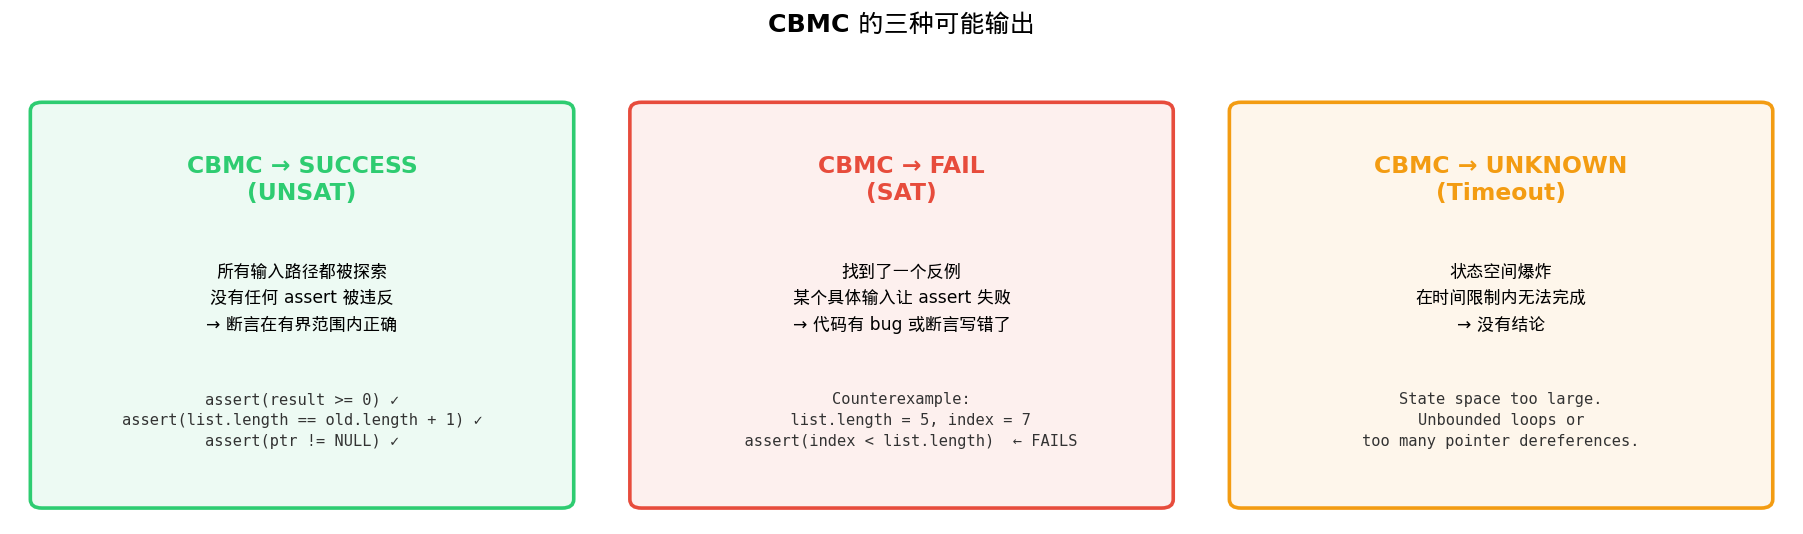

In [2]:
# 可视化 CBMC 的三种结果
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scenarios = [
    {
        'title': 'CBMC → SUCCESS\n(UNSAT)',
        'color': '#2ecc71',
        'icon': '✓',
        'desc': '所有输入路径都被探索\n没有任何 assert 被违反\n→ 断言在有界范围内正确',
        'detail': 'assert(result >= 0) ✓\nassert(list.length == old.length + 1) ✓\nassert(ptr != NULL) ✓'
    },
    {
        'title': 'CBMC → FAIL\n(SAT)',
        'color': '#e74c3c',
        'icon': '✗',
        'desc': '找到了一个反例\n某个具体输入让 assert 失败\n→ 代码有 bug 或断言写错了',
        'detail': 'Counterexample:\n  list.length = 5, index = 7\n  assert(index < list.length)  ← FAILS'
    },
    {
        'title': 'CBMC → UNKNOWN\n(Timeout)',
        'color': '#f39c12',
        'icon': '?',
        'desc': '状态空间爆炸\n在时间限制内无法完成\n→ 没有结论',
        'detail': 'State space too large.\nUnbounded loops or\ntoo many pointer dereferences.'
    }
]

for ax, s in zip(axes, scenarios):
    ax.set_facecolor(s['color'] + '22')
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
        boxstyle='round,pad=0.02', linewidth=2,
        edgecolor=s['color'], facecolor=s['color'] + '15'))
    ax.text(0.5, 0.85, s['title'], ha='center', va='top', fontsize=13,
            fontweight='bold', color=s['color'], transform=ax.transAxes)
    ax.text(0.5, 0.60, s['desc'], ha='center', va='top', fontsize=9.5,
            transform=ax.transAxes, linespacing=1.6)
    ax.text(0.5, 0.30, s['detail'], ha='center', va='top', fontsize=8.5,
            transform=ax.transAxes, family='monospace',
            color='#333', linespacing=1.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

fig.suptitle('CBMC 的三种可能输出', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 2：Proof Harness 是什么

CBMC 不能直接对整个程序做验证。你需要为每个函数写一个**proof harness**（证明框架）。

Harness 做三件事：
1. **建立有效输入**：用 `__CPROVER_assume()` 约束输入在合法范围内
2. **调用被验证函数**
3. **写出你想验证的属性**：用 `assert()` 表达"函数调用后，这些事情必须成立"

下面是 AWS 工程师为 `aws_array_list_erase` 写的 GT（Ground Truth）harness：

In [3]:
gt_harness = '''
void aws_array_list_erase_harness() {
    struct aws_array_list list;   // 声明一个 array list
    size_t index;                 // 要删除的位置（非确定性）

    // ① ASSUMES：告诉 CBMC 只考虑有效输入
    __CPROVER_assume(aws_array_list_is_bounded(&list, MAX_INITIAL_ITEM_ALLOCATION, MAX_ITEM_SIZE));
    ensure_array_list_has_allocated_data_member(&list);
    __CPROVER_assume(aws_array_list_is_valid(&list));

    // ② 保存调用前状态（用来和调用后对比）
    struct aws_array_list old = list;
    struct store_byte_from_buffer old_byte;
    save_byte_from_array((uint8_t *)list.data, list.current_size, &old_byte);

    // ③ 调用被验证函数
    if (aws_array_list_erase(&list, index) == AWS_OP_SUCCESS) {

        // ④ ASSERTS（成功时的后置条件）
        assert(list.length == old.length - 1);        // 长度减一
        assert(list.item_size == old.item_size);       // item_size 不变
        assert(list.alloc == old.alloc);               // 分配器不变
        assert(list.current_size == old.current_size); // 容量不变
        assert(index < old.length);                    // 索引必须合法

    } else {
        // ④' 失败时：列表应该没有变化
        assert_array_list_equivalence(&list, &old, &old_byte);
    }
    // 无论成败，数据结构必须有效
    assert(aws_array_list_is_valid(&list));
}
'''

print('AWS 工程师写的 GT Harness (aws_array_list_erase):')
print(gt_harness)

print('\n共有断言 (assert):',
      gt_harness.count('assert(') + gt_harness.count('assert_array'), '条')
print('共有假设 (assume):', gt_harness.count('__CPROVER_assume'), '条')

AWS 工程师写的 GT Harness (aws_array_list_erase):

void aws_array_list_erase_harness() {
    struct aws_array_list list;   // 声明一个 array list
    size_t index;                 // 要删除的位置（非确定性）

    // ① ASSUMES：告诉 CBMC 只考虑有效输入
    __CPROVER_assume(aws_array_list_is_bounded(&list, MAX_INITIAL_ITEM_ALLOCATION, MAX_ITEM_SIZE));
    ensure_array_list_has_allocated_data_member(&list);
    __CPROVER_assume(aws_array_list_is_valid(&list));

    // ② 保存调用前状态（用来和调用后对比）
    struct aws_array_list old = list;
    struct store_byte_from_buffer old_byte;
    save_byte_from_array((uint8_t *)list.data, list.current_size, &old_byte);

    // ③ 调用被验证函数
    if (aws_array_list_erase(&list, index) == AWS_OP_SUCCESS) {

        // ④ ASSERTS（成功时的后置条件）
        assert(list.length == old.length - 1);        // 长度减一
        assert(list.item_size == old.item_size);       // item_size 不变
        assert(list.alloc == old.alloc);               // 分配器不变
        assert(list.current_size == old.current_size); // 容量不变
       

---
## Part 3：实验流程 — LLM 怎么生成 Harness

我们让 LLM（gpt-oss-120b）生成 harness，然后用 CBMC 检验，根据结果给 LLM 反馈，循环最多 15 次：

```
LLM 生成 iter_1_harness.c
        ↓
   CBMC 运行
     ↙    ↘      ↘
 SUCCESS   FAIL   UNKNOWN
   ↓        ↓        ↓
  完成   "修复这个断言"  "状态空间太大，简化一下"
              ↓        ↓
          LLM 生成 iter_2_harness.c
              ↓
           继续...
```

关键问题：**CBMC 返回 UNKNOWN 时，LLM 会怎么做？**

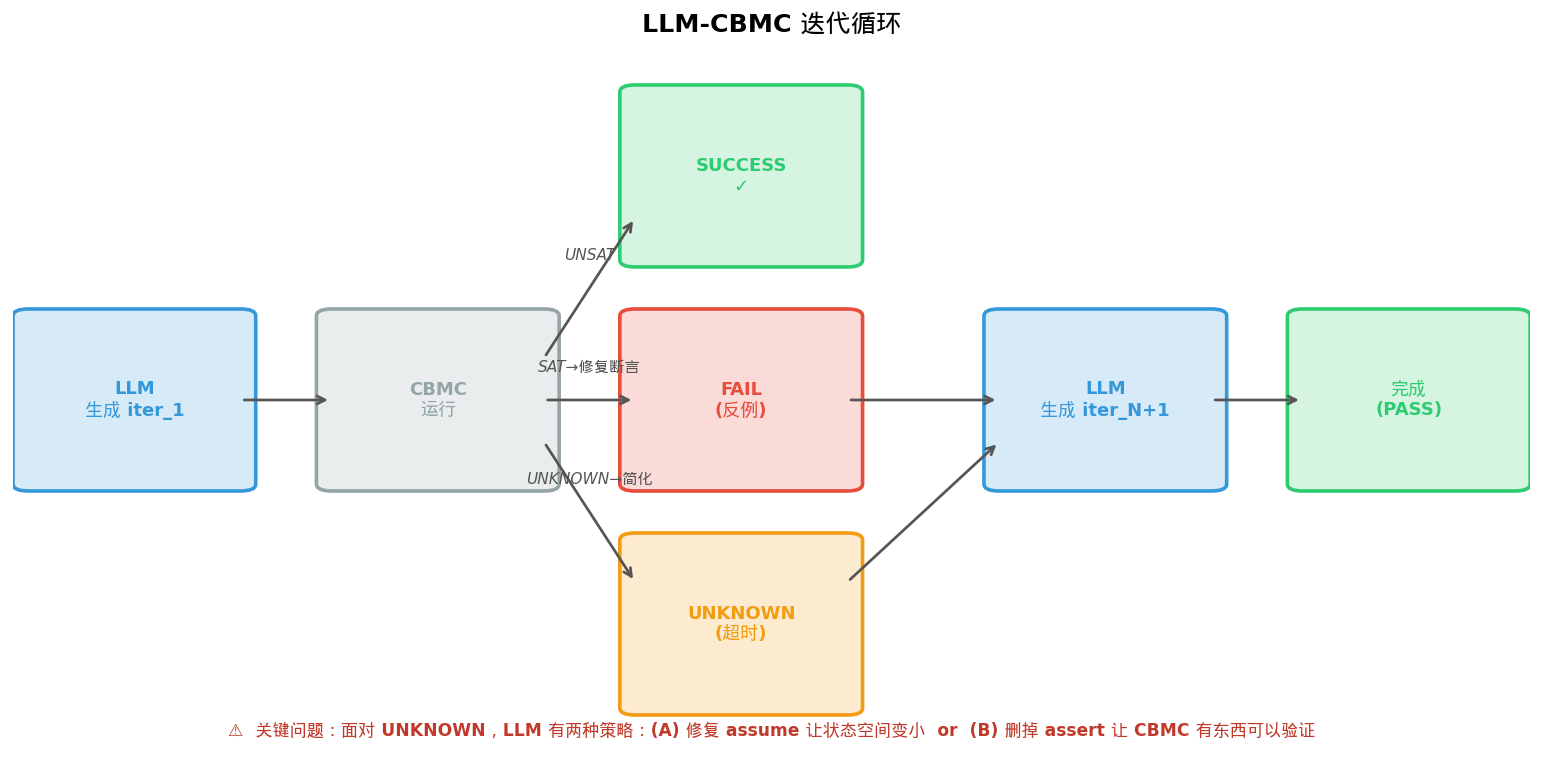

In [4]:
# 可视化迭代流程
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# 绘制流程框
boxes = [
    (0.08, 0.5, 'LLM\n生成 iter_1', '#3498db', 'white'),
    (0.28, 0.5, 'CBMC\n运行', '#95a5a6', 'white'),
    (0.48, 0.82, 'SUCCESS\n✓', '#2ecc71', 'white'),
    (0.48, 0.5,  'FAIL\n(反例)', '#e74c3c', 'white'),
    (0.48, 0.18, 'UNKNOWN\n(超时)', '#f39c12', 'white'),
    (0.72, 0.5, 'LLM\n生成 iter_N+1', '#3498db', 'white'),
    (0.92, 0.5, '完成\n(PASS)', '#2ecc71', 'white'),
]

for x, y, label, color, tc in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-0.07, y-0.12), 0.14, 0.24,
        boxstyle='round,pad=0.01', linewidth=2,
        edgecolor=color, facecolor=color + '33'))
    ax.text(x, y, label, ha='center', va='center', fontsize=10,
            fontweight='bold', color=color)

# 箭头
arrows = [
    (0.15, 0.5, 0.21, 0.5, ''),
    (0.35, 0.56, 0.41, 0.76, 'UNSAT'),
    (0.35, 0.5,  0.41, 0.5,  'SAT→修复断言'),
    (0.35, 0.44, 0.41, 0.24, 'UNKNOWN→简化'),
    (0.55, 0.5,  0.65, 0.5,  ''),
    (0.55, 0.24, 0.65, 0.44, ''),
    (0.79, 0.5,  0.85, 0.5,  ''),
]
for x1, y1, x2, y2, label in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.04, label,
                ha='center', fontsize=8.5, color='#555',
                style='italic')

# "UNKNOWN" 时的关键问题
ax.text(0.5, 0.02,
    '⚠️  关键问题：面对 UNKNOWN，LLM 有两种策略：'
    '(A) 修复 assume 让状态空间变小  or  (B) 删掉 assert 让 CBMC 有东西可以验证',
    ha='center', fontsize=9.5, color='#c0392b',
    fontweight='bold')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('LLM-CBMC 迭代循环', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Part 4：真实的 Sacrifice 案例 — aws_array_list_erase

这是我们观察到的现象：LLM 在 CBMC UNKNOWN 后，**删掉了 8 个断言**。

In [5]:
func = 'aws_array_list_erase'
result_dir = os.path.join(RESULTS, 'feedback_loop_A_gptoss120b', func)

with open(os.path.join(result_dir, 'summary.json')) as f:
    summary = json.load(f)

# 读取每次迭代的 harness
iter_files = sorted([f for f in os.listdir(result_dir)
                     if f.startswith('iter_') and f.endswith('_harness.c')])

iter_asserts = {}
iter_code = {}
for fname in iter_files:
    num = int(fname.split('_')[1])
    with open(os.path.join(result_dir, fname)) as f:
        code = f.read()
    iter_code[num] = code
    # 数 assert 行（排除 __CPROVER_assume 和 #include）
    n = sum(1 for line in code.splitlines()
            if 'assert(' in line and '__CPROVER_assume' not in line
            and not line.strip().startswith('//'))
    iter_asserts[num] = n

print(f'函数: {func}')
print(f'迭代次数: {len(summary["iterations"])}')
print()
for it in summary['iterations']:
    n = iter_asserts.get(it['iter'], '?')
    status_color = {'SUCCESS': '✅', 'FAIL': '❌', 
                    'UNKNOWN': '⚠️', 'COMPILE_ERROR': '🔧'}.get(it['verify'], '?')
    print(f"  Iter {it['iter']}: {status_color} {it['verify']:15s}  "
          f"assert 数量: {n}  action: {it['action']}")

函数: aws_array_list_erase
迭代次数: 3

  Iter 1: ⚠️ UNKNOWN          assert 数量: 15  action: initial
  Iter 2: ⚠️ UNKNOWN          assert 数量: 7  action: fix_unknown
  Iter 3: ✅ SUCCESS          assert 数量: 10  action: fix_unknown


In [6]:
# 对比 iter_1 和 iter_2 的断言
def extract_asserts(code):
    lines = []
    for line in code.splitlines():
        stripped = line.strip()
        if ('assert(' in stripped and
            '__CPROVER_assume' not in stripped and
            not stripped.startswith('//') and
            '#include' not in stripped):
            lines.append(stripped)
    return lines

asserts_1 = extract_asserts(iter_code[1])
asserts_2 = extract_asserts(iter_code[2])
set_1 = set(asserts_1)
set_2 = set(asserts_2)

print('='*65)
print(f'ITER 1 断言（{len(asserts_1)} 条）→ CBMC: UNKNOWN')
print('='*65)
for a in asserts_1:
    marker = '❌ DELETED' if a not in set_2 else '  kept   '
    print(f'  {marker}  {a}')

print()
print('='*65)
print(f'ITER 2 断言（{len(asserts_2)} 条）→ CBMC: SUCCESS')
print('='*65)
for a in asserts_2:
    marker = '✨ NEW' if a not in set_1 else '       '
    print(f'  {marker}  {a}')

print()
print(f'删除了 {len(set_1 - set_2)} 条断言，新增了 {len(set_2 - set_1)} 条断言')

ITER 1 断言（15 条）→ CBMC: UNKNOWN
    kept     assert(list.length == old.length - 1);
    kept     assert(list.alloc == old.alloc);
    kept     assert(list.item_size == old.item_size);
    kept     assert(list.data == old.data);
    kept     assert(list.current_size == old.current_size);
    kept     assert(list.length == old.length);
    kept     assert(list.alloc == old.alloc);
    kept     assert(list.item_size == old.item_size);
    kept     assert(list.data == old.data);
    kept     assert(list.current_size == old.current_size);
    kept     assert(list.alloc == old.alloc);
    kept     assert(list.item_size == old.item_size);
    kept     assert(list.data == old.data);
    kept     assert(list.current_size == old.current_size);
    kept     assert(aws_array_list_is_valid(&list));

ITER 2 断言（7 条）→ CBMC: SUCCESS
           assert(list.length == old.length - 1);
           assert(list.length == old.length);
           assert(list.alloc == old.alloc);
           assert(list.item_size 

In [7]:
# 与 GT 对比：哪些 GT 断言在 iter_1 存在但被删了，哪些从未生成过
gt_asserts_raw = [
    'assert(list.length == old.length - 1)',
    'assert(list.item_size == old.item_size)',
    'assert(list.alloc == old.alloc)',
    'assert(list.current_size == old.current_size)',
    'assert(index < old.length)',
    'assert_array_list_equivalence(&list, &old, &old_byte)',
    'assert(aws_array_list_is_valid(&list))',
]

print('GT Harness 断言 vs LLM 最终 Harness (iter_2):')
print()
final_code = '\n'.join(asserts_2)
for gt in gt_asserts_raw:
    # 宽松匹配：检查关键词是否出现
    key = gt.replace('assert(', '').replace(')', '').strip().split('==')[0].strip()
    appeared_any = any(key in a for a in asserts_1 + asserts_2)
    in_final = any(key in a for a in asserts_2)
    if in_final:
        status = '✅ 匹配'
    elif appeared_any:
        status = '⚠️ 曾生成后删除 (SACRIFICE)'
    else:
        status = '❌ 从未生成 (KNOWLEDGE GAP)'
    print(f'  {status}  {gt}')

GT Harness 断言 vs LLM 最终 Harness (iter_2):

  ✅ 匹配  assert(list.length == old.length - 1)
  ✅ 匹配  assert(list.item_size == old.item_size)
  ✅ 匹配  assert(list.alloc == old.alloc)
  ✅ 匹配  assert(list.current_size == old.current_size)
  ❌ 从未生成 (KNOWLEDGE GAP)  assert(index < old.length)
  ❌ 从未生成 (KNOWLEDGE GAP)  assert_array_list_equivalence(&list, &old, &old_byte)
  ✅ 匹配  assert(aws_array_list_is_valid(&list))


---
## Part 5：PASS 率 vs Recall — 为什么 PASS 率是误导性指标

> Part 4 是一个函数的故事。现在把镜头拉远：在全部 83 个函数上，删除行为对质量的影响有多大？先定义两个 RQ1 指标。

**PASS 率**：LLM harness 通过 CBMC 验证的函数比例。  
**Recall**：LLM harness 中，与 GT 断言**匹配的比例**（在 GT assumes 下重新验证）。

核心发现：**PASS 率越高的条件，Recall 不一定越高，甚至可能更低！**

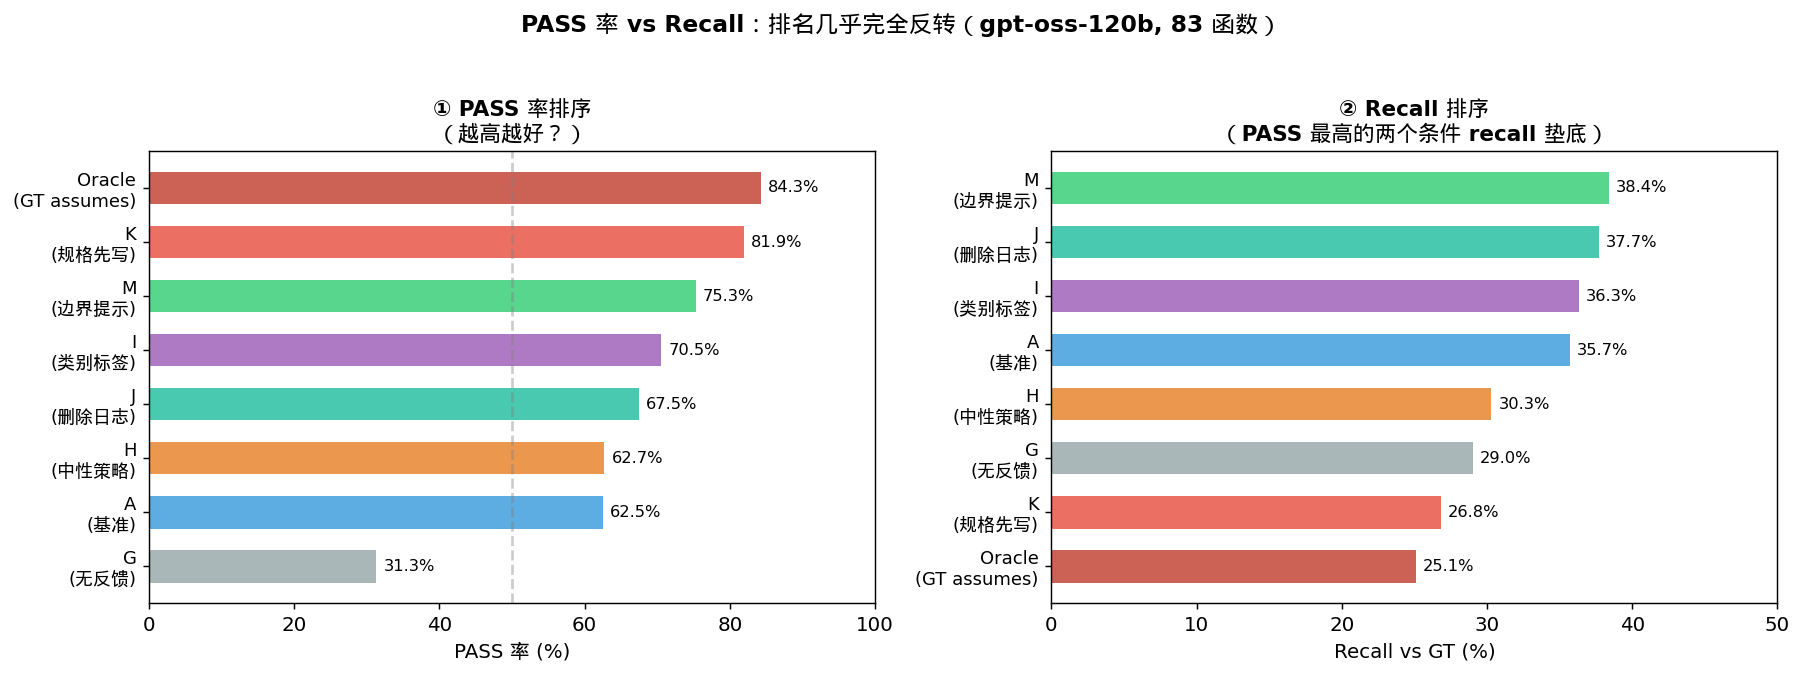

PASS 排序 : Oracle(GT assumes) > K(规格先写) > M(边界提示) > I(类别标签) > J(删除日志) > H(中性策略) > A(基准) > G(无反馈)
Recall 排序: M(边界提示) > J(删除日志) > I(类别标签) > A(基准) > H(中性策略) > G(无反馈) > K(规格先写) > Oracle(GT assumes)


In [8]:
# 实验结果数据（canonical：paper.tex Table 2 / tab:rq1_main，2026-06-10 版）
# recall = 对 GT 断言的 strict Jaccard 匹配比例；sacrifice = UNKNOWN 触发的删/弱化 / 全部删/弱化
conditions_data = {
    'G\n(无反馈)':      {'pass': 31.3, 'recall': 0.290, 'sacrifice': None,  'color': '#95a5a6'},
    'H\n(中性策略)':    {'pass': 62.7, 'recall': 0.303, 'sacrifice': 86.3,  'color': '#e67e22'},
    'A\n(基准)':        {'pass': 62.5, 'recall': 0.357, 'sacrifice': 81.8,  'color': '#3498db'},
    'I\n(类别标签)':    {'pass': 70.5, 'recall': 0.363, 'sacrifice': 92.7,  'color': '#9b59b6'},
    'J\n(删除日志)':    {'pass': 67.5, 'recall': 0.377, 'sacrifice': 93.0,  'color': '#1abc9c'},
    'K\n(规格先写)':    {'pass': 81.9, 'recall': 0.268, 'sacrifice': 25.0,  'color': '#e74c3c'},
    'Oracle\n(GT assumes)': {'pass': 84.3, 'recall': 0.251, 'sacrifice': 11.8, 'color': '#c0392b'},
    'M\n(边界提示)':    {'pass': 75.3, 'recall': 0.384, 'sacrifice': 0.0,   'color': '#2ecc71'},
}

conds_with_recall = {k: v for k, v in conditions_data.items() if v['recall'] is not None}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：PASS 率排序
ax = axes[0]
names = list(conds_with_recall.keys())
passes = [conds_with_recall[n]['pass'] for n in names]
colors = [conds_with_recall[n]['color'] for n in names]
sorted_by_pass = sorted(zip(passes, names, colors), reverse=True)
p_sorted, n_sorted, c_sorted = zip(*sorted_by_pass)
ax.barh(range(len(n_sorted)), p_sorted, color=c_sorted, alpha=0.8, height=0.6)
ax.set_yticks(range(len(n_sorted)))
ax.set_yticklabels(n_sorted, fontsize=10)
ax.set_xlabel('PASS 率 (%)', fontsize=11)
ax.set_title('① PASS 率排序\n（越高越好？）', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)
for i, p in enumerate(p_sorted):
    ax.text(p + 1, i, f'{p:.1f}%', va='center', fontsize=9)
ax.axvline(50, color='gray', linestyle='--', alpha=0.4)
ax.invert_yaxis()

# 右图：Recall 排序（注意顺序大幅重排！）
ax = axes[1]
recalls = [conds_with_recall[n]['recall'] * 100 for n in names]
sorted_by_recall = sorted(zip(recalls, names, colors), reverse=True)
r_sorted, n_sorted2, c_sorted2 = zip(*sorted_by_recall)
ax.barh(range(len(n_sorted2)), r_sorted, color=c_sorted2, alpha=0.8, height=0.6)
ax.set_yticks(range(len(n_sorted2)))
ax.set_yticklabels(n_sorted2, fontsize=10)
ax.set_xlabel('Recall vs GT (%)', fontsize=11)
ax.set_title('② Recall 排序\n（PASS 最高的两个条件 recall 垫底）', fontsize=12, fontweight='bold')
ax.set_xlim(0, 50)
for i, r in enumerate(r_sorted):
    ax.text(r + 0.5, i, f'{r:.1f}%', va='center', fontsize=9)
ax.invert_yaxis()

fig.suptitle('PASS 率 vs Recall：排名几乎完全反转（gpt-oss-120b, 83 函数）',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('PASS 排序 :', ' > '.join(n.replace('\n', '') for n in n_sorted))
print('Recall 排序:', ' > '.join(n.replace('\n', '') for n in n_sorted2))

---
## Part 6：为什么排名会反转 — 三种机制

| 条件 | 高 PASS 的原因 | 低 Recall 的原因 |
|------|--------------|----------------|
| **Oracle** | GT assumes 提供了完美的状态约束 | LLM "懒" — assumes 太好了，任何简单断言都能通过，LLM 写了最少的断言 |
| **K** | NL 合约先写好，harness 从强约束出发 | NL 合约本身不完整，遗漏了 GT 的 postconditions |
| **A** | 迭代修复提高了 PASS | 部分正确断言在 UNKNOWN 压力下被删掉了（sacrifice）|
| **M** | 边界提示消除了 UNKNOWN | 没有删除行为，保留了所有正确断言 |

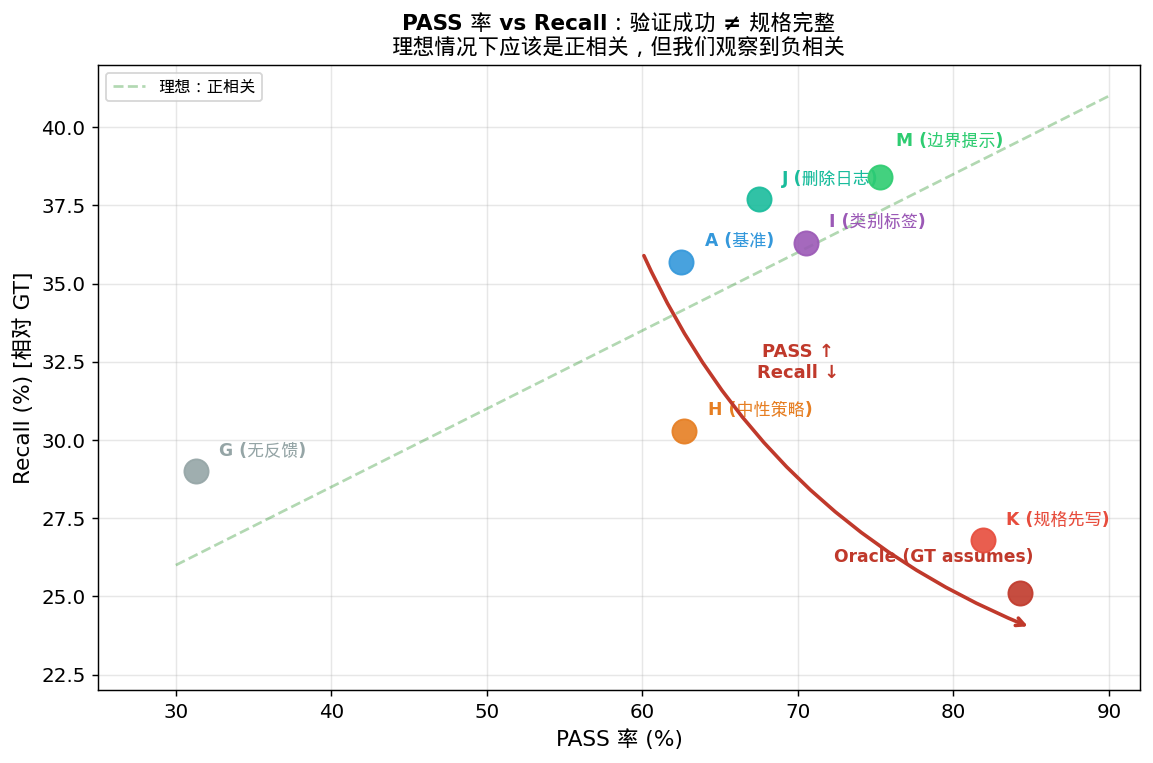

In [9]:
# 散点图：PASS 率 vs Recall，显示反转关系
fig, ax = plt.subplots(figsize=(9, 6))

for name, d in conds_with_recall.items():
    short = name.replace('\n', ' ')
    ax.scatter(d['pass'], d['recall'] * 100, s=180, color=d['color'],
               zorder=5, alpha=0.9)
    offset_x = 1.5
    offset_y = 0.5
    if 'Oracle' in name:
        offset_x = -12; offset_y = 1
    elif 'M' in name:
        offset_x = 1; offset_y = 1
    ax.annotate(short,
                xy=(d['pass'], d['recall'] * 100),
                xytext=(d['pass'] + offset_x, d['recall'] * 100 + offset_y),
                fontsize=9.5, color=d['color'], fontweight='bold')

# 反趋势箭头
ax.annotate('', xy=(85, 24), xytext=(60, 36),
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2, 
                    connectionstyle='arc3,rad=0.2'))
ax.text(70, 32, 'PASS ↑\nRecall ↓', color='#c0392b', fontsize=10,
        fontweight='bold', ha='center')

ax.set_xlabel('PASS 率 (%)', fontsize=12)
ax.set_ylabel('Recall (%) [相对 GT]', fontsize=12)
ax.set_title('PASS 率 vs Recall：验证成功 ≠ 规格完整\n'
             '理想情况下应该是正相关，但我们观察到负相关',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(25, 92)
ax.set_ylim(22, 42)

# 理想线
ax.plot([30, 90], [26, 41], 'g--', alpha=0.3, label='理想：正相关')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Part 7：两个"删除"数字的区别 — 删得多 ≠ 漏 bug 多

容易混淆的两组数字（都是 A 条件 / gpt-oss-120b）：

- **81.8% sacrifice ratio**（RQ1，迭代日志层面）：所有删除/弱化事件中，81.8% 是被 **UNKNOWN** 触发的（不是 FAIL 触发的合法修复）。→ 说明删除行为的**动机**是逃避状态空间爆炸。
- **90.2% KG**（RQ2，silenced-bug 层面）：41 个被放走的 bug 中，90.2% 归因为**从未生成过**对应断言（知识缺口），SAC 反而是 0%。

这不是矛盾——它们的分母不同：

| 数字 | 分母 | 回答的问题 |
|---|---|---|
| 81.8% | 所有删除事件 | LLM **为什么**删断言？ |
| 90.2% KG / 0% SAC | 被放走的 bug | 漏掉的 bug 是**哪条路**漏的？ |

**关键洞察**：gptoss 删得很凶（81.8% 由 UNKNOWN 触发），但删掉的大多是它自己过度生成的、本来也抓不到 mutant 的断言；真正放走 bug 的是它**从来不会写**的断言（CA 容量算术、FC-RV 返回值检查）。SAC 真正造成安全损害的是 **Claude**（37.5%，见 Part 14）——能力越强，写出的正确断言越多，删除才越伤。


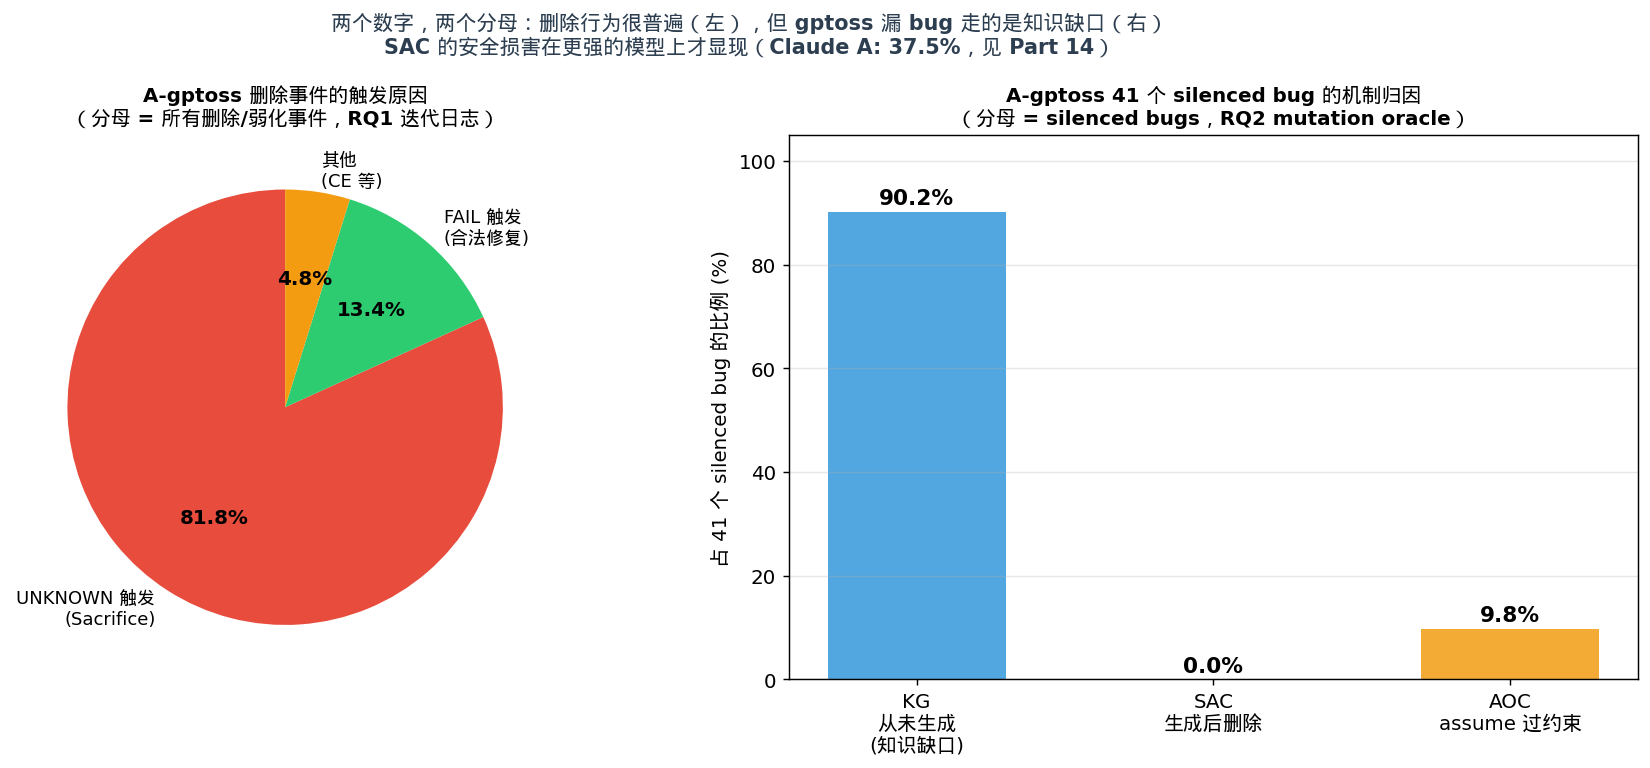

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：A 条件删除事件的触发原因（sacrifice ratio 的分母 = 所有删除事件）
ax = axes[0]
labels = ['UNKNOWN 触发\n(Sacrifice)', 'FAIL 触发\n(合法修复)', '其他\n(CE 等)']
sizes = [81.8, 13.4, 4.8]
colors = ['#e74c3c', '#2ecc71', '#f39c12']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 10})
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title('A-gptoss 删除事件的触发原因\n（分母 = 所有删除/弱化事件，RQ1 迭代日志）',
             fontsize=11, fontweight='bold')

# 右图：A-gptoss 41 个 silenced bug 的机制归因（RQ2 oracle）
ax = axes[1]
categories = ['KG\n从未生成\n(知识缺口)', 'SAC\n生成后删除', 'AOC\nassume 过约束']
values = [90.2, 0.0, 9.8]
colors_2 = ['#3498db', '#e74c3c', '#f39c12']
bars = ax.bar(categories, values, color=colors_2, alpha=0.85, width=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{v}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('占 41 个 silenced bug 的比例 (%)', fontsize=11)
ax.set_title('A-gptoss 41 个 silenced bug 的机制归因\n（分母 = silenced bugs，RQ2 mutation oracle）',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    '两个数字，两个分母：删除行为很普遍（左），但 gptoss 漏 bug 走的是知识缺口（右）\n'
    'SAC 的安全损害在更强的模型上才显现（Claude A: 37.5%，见 Part 14）',
    fontsize=11.5, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.show()

---
## Part 8：8 个实验条件，每个测什么

看完了"删除行为存在且很普遍"（Part 4–7），自然的问题是：**它为什么发生？**我们设计了 8 个条件来系统地**隔离**候选解释——每个条件相对基准 A 只改变一个变量，像做对照实验一样逐个排除/确认机制。

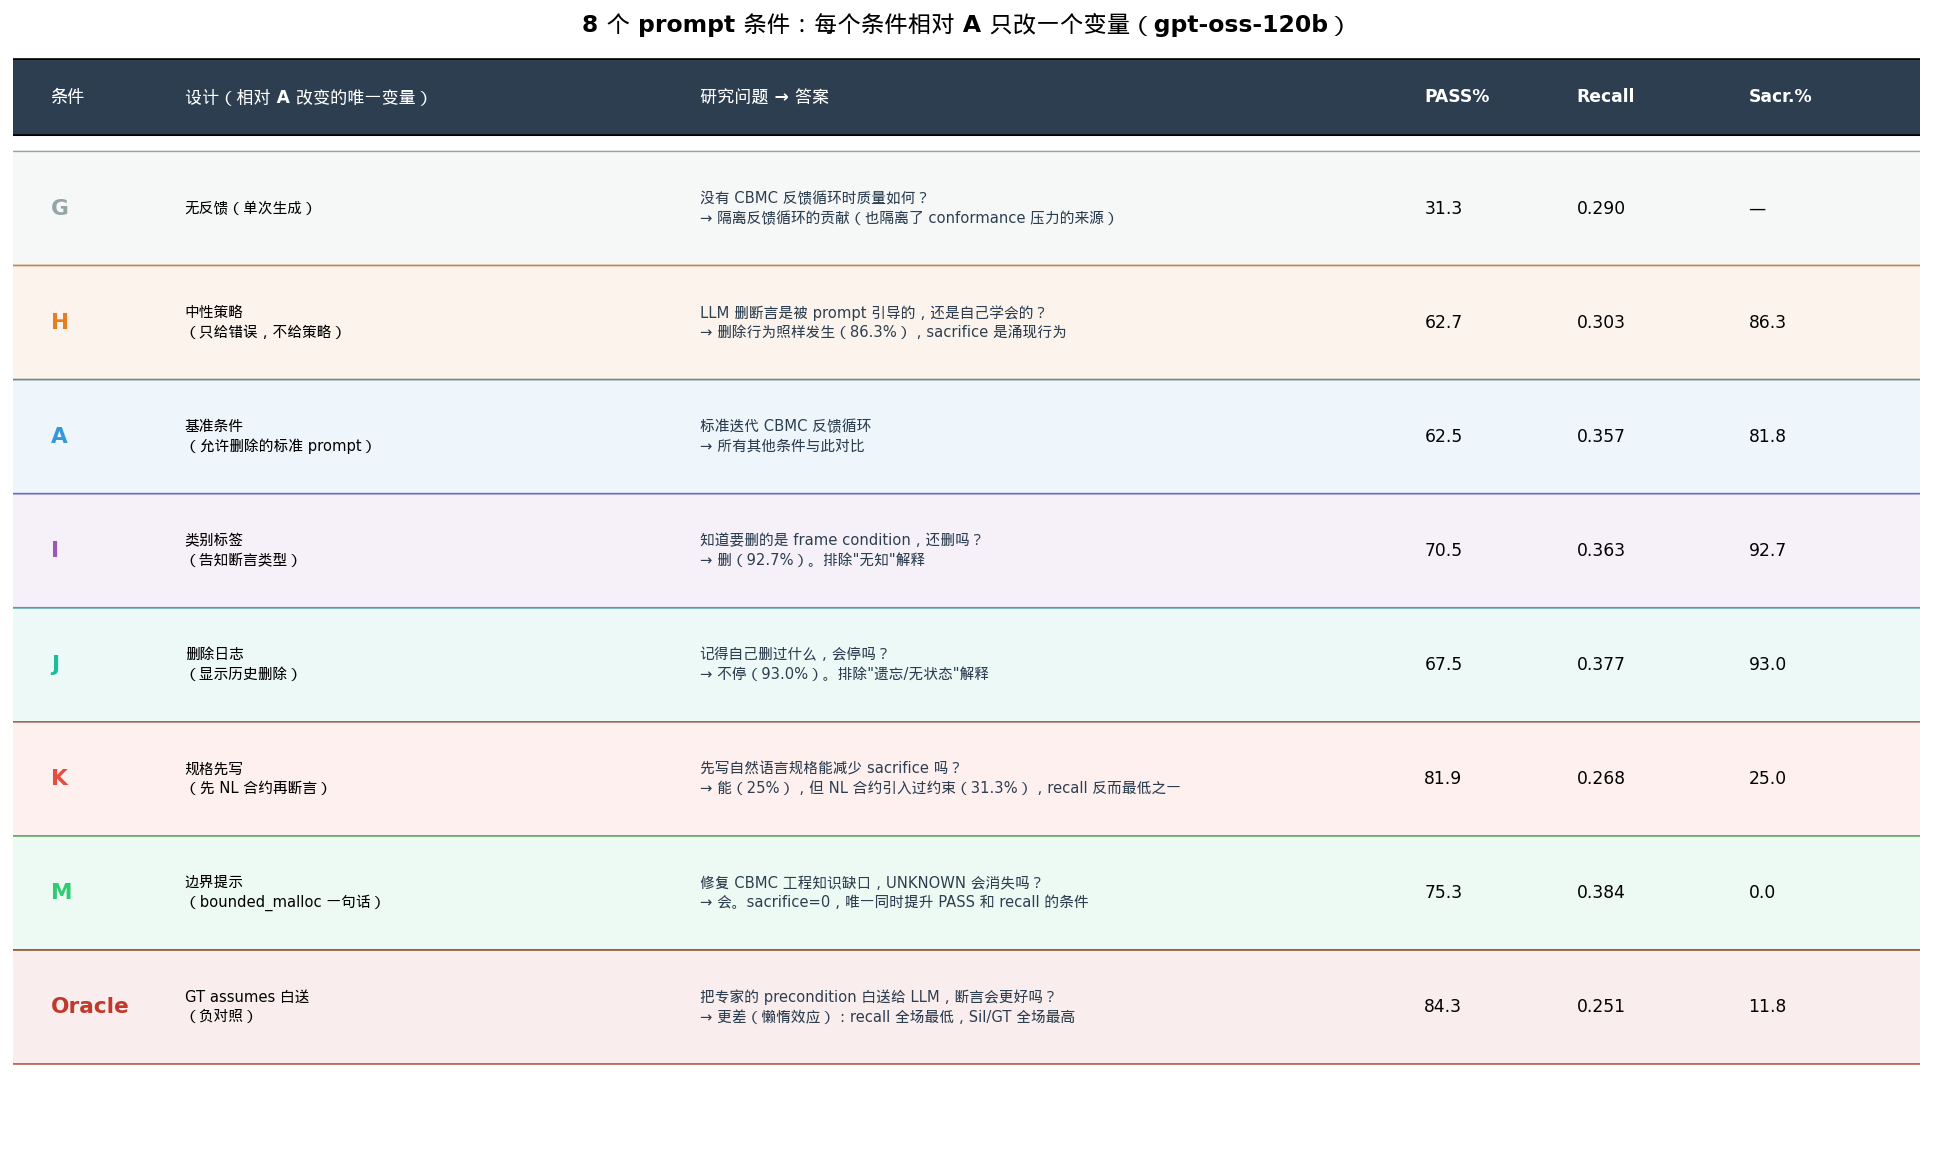

In [11]:
# 8 个条件的设计意图一览（canonical 数字，paper.tex Table 2）
conditions_info = [
    ('G', '无反馈（单次生成）', '没有 CBMC 反馈循环时质量如何？\n→ 隔离反馈循环的贡献（也隔离了 conformance 压力的来源）', 31.3, 0.290, None, '#95a5a6'),
    ('H', '中性策略\n（只给错误，不给策略）', 'LLM 删断言是被 prompt 引导的，还是自己学会的？\n→ 删除行为照样发生（86.3%），sacrifice 是涌现行为', 62.7, 0.303, 86.3, '#e67e22'),
    ('A', '基准条件\n（允许删除的标准 prompt）', '标准迭代 CBMC 反馈循环\n→ 所有其他条件与此对比', 62.5, 0.357, 81.8, '#3498db'),
    ('I', '类别标签\n（告知断言类型）', '知道要删的是 frame condition，还删吗？\n→ 删（92.7%）。排除"无知"解释', 70.5, 0.363, 92.7, '#9b59b6'),
    ('J', '删除日志\n（显示历史删除）', '记得自己删过什么，会停吗？\n→ 不停（93.0%）。排除"遗忘/无状态"解释', 67.5, 0.377, 93.0, '#1abc9c'),
    ('K', '规格先写\n（先 NL 合约再断言）', '先写自然语言规格能减少 sacrifice 吗？\n→ 能（25%），但 NL 合约引入过约束（31.3%），recall 反而最低之一', 81.9, 0.268, 25.0, '#e74c3c'),
    ('M', '边界提示\n（bounded_malloc 一句话）', '修复 CBMC 工程知识缺口，UNKNOWN 会消失吗？\n→ 会。sacrifice=0，唯一同时提升 PASS 和 recall 的条件', 75.3, 0.384, 0.0, '#2ecc71'),
    ('Oracle', 'GT assumes 白送\n（负对照）', '把专家的 precondition 白送给 LLM，断言会更好吗？\n→ 更差（懒惰效应）：recall 全场最低，Sil/GT 全场最高', 84.3, 0.251, 11.8, '#c0392b'),
]

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis('off')

col_headers = ['条件', '设计（相对 A 改变的唯一变量）', '研究问题 → 答案', 'PASS%', 'Recall', 'Sacr.%']
col_x = [0.02, 0.09, 0.36, 0.74, 0.82, 0.91]
row_h = 0.105

ax.add_patch(mpatches.FancyBboxPatch((0, 0.93), 1.0, 0.06,
    boxstyle='round,pad=0.005', facecolor='#2c3e50', transform=ax.transAxes))
for x, h in zip(col_x, col_headers):
    ax.text(x, 0.96, h, fontsize=9.5, fontweight='bold', color='white',
            transform=ax.transAxes, va='center')

for i, (cond, intent, question, pass_r, recall, sacr, color) in enumerate(conditions_info):
    y = 0.92 - (i + 1) * row_h
    ax.add_patch(mpatches.FancyBboxPatch((0, y - 0.005), 1.0, row_h - 0.01,
        boxstyle='round,pad=0.005', facecolor=color + '15', transform=ax.transAxes,
        linewidth=0.8, edgecolor=color))
    ax.text(col_x[0], y + row_h/2 - 0.01, cond, fontsize=12, fontweight='bold',
            color=color, transform=ax.transAxes, va='center')
    ax.text(col_x[1], y + row_h/2 - 0.01, intent, fontsize=8.2,
            transform=ax.transAxes, va='center', linespacing=1.4)
    ax.text(col_x[2], y + row_h/2 - 0.01, question, fontsize=8.2,
            transform=ax.transAxes, va='center', linespacing=1.4, color='#2c3e50')
    ax.text(col_x[3], y + row_h/2 - 0.01, f'{pass_r:.1f}', fontsize=9.5,
            transform=ax.transAxes, va='center')
    ax.text(col_x[4], y + row_h/2 - 0.01,
            f'{recall:.3f}' if recall is not None else '—', fontsize=9.5,
            transform=ax.transAxes, va='center')
    ax.text(col_x[5], y + row_h/2 - 0.01,
            f'{sacr:.1f}' if sacr is not None else '—', fontsize=9.5,
            transform=ax.transAxes, va='center')

ax.set_title('8 个 prompt 条件：每个条件相对 A 只改一个变量（gpt-oss-120b）',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## Part 9：Deletion_scope — Panic 删除 vs 精准删除

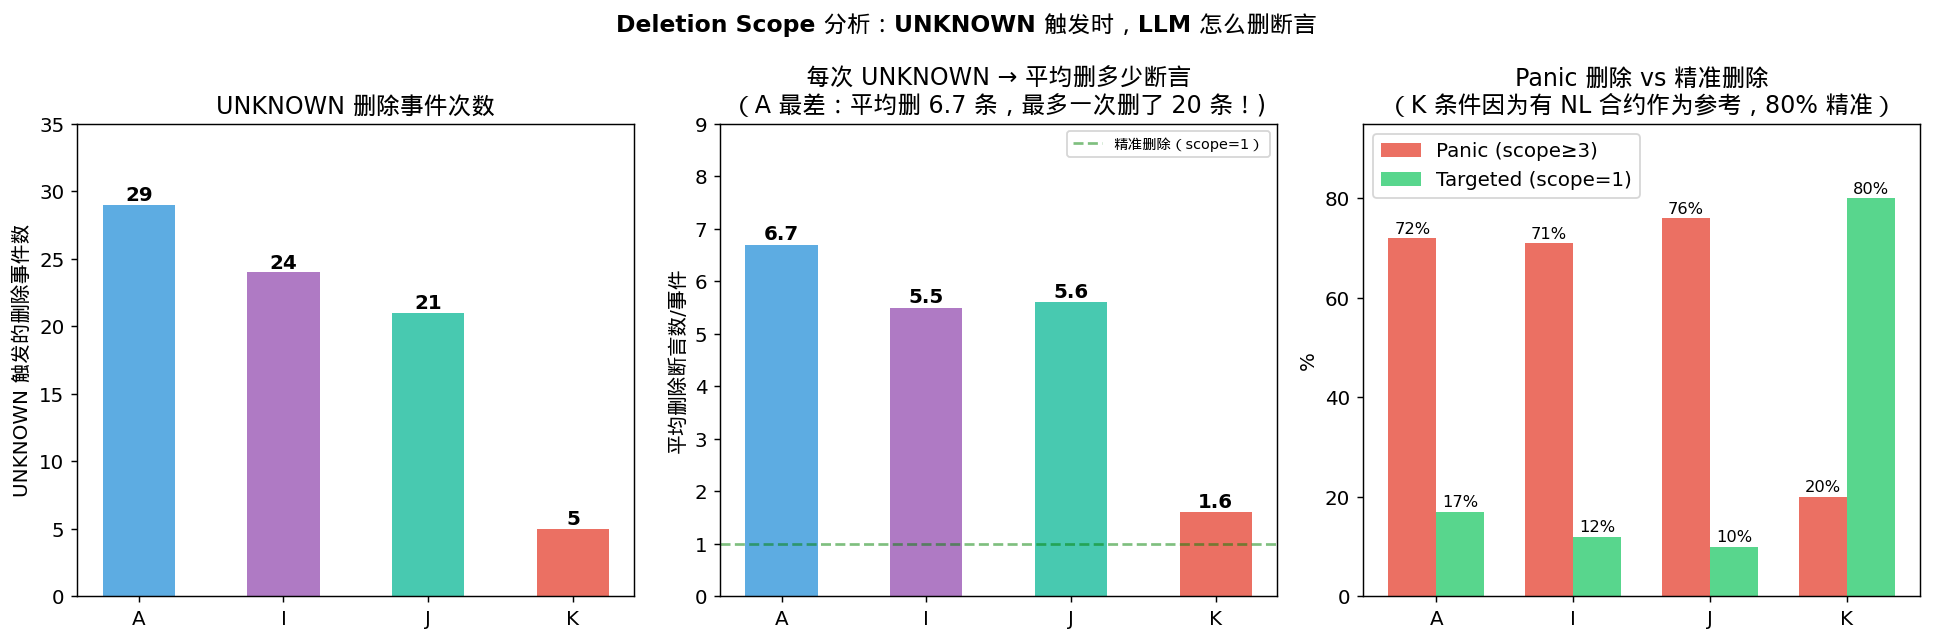


解读：
  A/I/J：72-76% 是 panic 删除——CBMC 超时了，LLM 不知道哪个断言有问题，索性大扫清
  K：   80% 精准删除——因为有自己写的 NL 合约作参考，能定位到具体哪条断言冲突
  M：   0 次删除——CBMC 不再 UNKNOWN，没有删除压力


In [12]:
# 来自 research_design.md 的 deletion_scope 数据
deletion_scope_data = {
    'A':      {'events': 29, 'mean_scope': 6.7, 'panic_pct': 72, 'targeted_pct': 17, 'color': '#3498db'},
    'I':      {'events': 24, 'mean_scope': 5.5, 'panic_pct': 71, 'targeted_pct': 12, 'color': '#9b59b6'},
    'J':      {'events': 21, 'mean_scope': 5.6, 'panic_pct': 76, 'targeted_pct': 10, 'color': '#1abc9c'},
    'K':      {'events': 5,  'mean_scope': 1.6, 'panic_pct': 20, 'targeted_pct': 80, 'color': '#e74c3c'},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 左图：UNKNOWN 事件次数
ax = axes[0]
cnames = list(deletion_scope_data.keys())
events = [deletion_scope_data[c]['events'] for c in cnames]
colors_ds = [deletion_scope_data[c]['color'] for c in cnames]
ax.bar(cnames, events, color=colors_ds, alpha=0.8, width=0.5)
ax.set_ylabel('UNKNOWN 触发的删除事件数')
ax.set_title('UNKNOWN 删除事件次数')
for i, (c, e) in enumerate(zip(cnames, events)):
    ax.text(i, e + 0.3, str(e), ha='center', fontweight='bold')
ax.set_ylim(0, 35)

# 中图：平均每次删多少断言
ax = axes[1]
means = [deletion_scope_data[c]['mean_scope'] for c in cnames]
ax.bar(cnames, means, color=colors_ds, alpha=0.8, width=0.5)
ax.set_ylabel('平均删除断言数/事件')
ax.set_title('每次 UNKNOWN → 平均删多少断言\n（A 最差：平均删 6.7 条，最多一次删了 20 条！)')
for i, (c, m) in enumerate(zip(cnames, means)):
    ax.text(i, m + 0.1, f'{m:.1f}', ha='center', fontweight='bold')
ax.set_ylim(0, 9)
ax.axhline(1, color='green', linestyle='--', alpha=0.5, label='精准删除（scope=1）')
ax.legend(fontsize=8)

# 右图：Panic vs Targeted 比例
ax = axes[2]
panic = [deletion_scope_data[c]['panic_pct'] for c in cnames]
targeted = [deletion_scope_data[c]['targeted_pct'] for c in cnames]
x = np.arange(len(cnames))
w = 0.35
bars1 = ax.bar(x - w/2, panic, width=w, label='Panic (scope≥3)',
               color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + w/2, targeted, width=w, label='Targeted (scope=1)',
               color='#2ecc71', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(cnames)
ax.set_ylabel('%')
ax.set_title('Panic 删除 vs 精准删除\n（K 条件因为有 NL 合约作为参考，80% 精准）')
ax.legend()
ax.set_ylim(0, 95)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)

fig.suptitle('Deletion Scope 分析：UNKNOWN 触发时，LLM 怎么删断言',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n解读：')
print('  A/I/J：72-76% 是 panic 删除——CBMC 超时了，LLM 不知道哪个断言有问题，索性大扫清')
print('  K：   80% 精准删除——因为有自己写的 NL 合约作参考，能定位到具体哪条断言冲突')
print('  M：   0 次删除——CBMC 不再 UNKNOWN，没有删除压力')

---
## Part 10：统计显著性

> 注：下面的图展示的是未校正的 p 值（与历史数据一致）。论文最终版对这 11 个检验做了 **Holm 校正**并补了 rank-biserial 效应量：M 系列四项（M>Oracle/M>K/M>H/J>H）校正后仍显著，A>Oracle、A>K、A>H 三项**校正后失去显著性**（论文 Table 4 以 † 标注）。

用 Wilcoxon signed-rank 检验验证 recall 差异是否在统计上显著（在 83 个函数上的配对检验）。

In [13]:
from scipy.stats import wilcoxon

def load_recall(path):
    with open(path) as f:
        entries = json.load(f)
    return {e['func']: (e['harness_recall'] if e['harness_recall'] is not None else 0.0)
            for e in entries if e['gt_harness_count'] > 0}

cond_paths = {
    'A':      os.path.join(EVAL, 'cross_verify_results_condA_gptoss120b.json'),
    'H':      os.path.join(EVAL, 'cross_verify_results_condH_gptoss120b.json'),
    'G':      os.path.join(EVAL, 'cross_verify_results_condG_gptoss120b.json'),
    'K':      os.path.join(EVAL, 'cross_verify_results_condK_gptoss120b.json'),
    'Oracle': os.path.join(EVAL, 'cross_verify_results_condOracle_gptoss120b.json'),
    'M':      os.path.join(EVAL, 'cross_verify_results_condM_gptoss120b.json'),
}

recalls = {k: load_recall(v) for k, v in cond_paths.items()}

# 关键比较
tests = [
    ('M', 'Oracle', '懒惰效应反转：M > Oracle'),
    ('M', 'K',      'PASS-Recall 反转：M > K'),
    ('M', 'H',      '边界提示效果：M > H'),
    ('A', 'Oracle', '懒惰效应：A > Oracle（有 GT assumes 反而更差）'),
    ('A', 'K',      '规格先写不提升 recall：A > K'),
    ('A', 'H',      '策略指导有效：A > H（同等 PASS 下）'),
    ('M', 'A',      'M vs A（微弱，ns）'),
]

print(f'{"比较":<30} {"n":>4} {"Δmean recall":>13} {"p (one-sided)":>15} {"显著性":>8}')
print('-'*75)

results_for_plot = []
for c1, c2, label in tests:
    shared = sorted(set(recalls[c1]) & set(recalls[c2]))
    v1 = np.array([recalls[c1][f] for f in shared])
    v2 = np.array([recalls[c2][f] for f in shared])
    diff = v1 - v2
    nonzero = np.sum(diff != 0)
    mean_diff = np.mean(v1) - np.mean(v2)
    if nonzero >= 6:
        stat, p = wilcoxon(v1, v2, alternative='greater')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        results_for_plot.append((label[:35], mean_diff, p, sig))
        print(f'{label:<45} {len(shared):>4} {mean_diff:>+13.4f} {p:>15.4f} {sig:>8}')

print()
print('* p<0.05, ** p<0.01, *** p<0.001 (Wilcoxon signed-rank, one-sided, per-function strict recall)')

比较                                n  Δmean recall   p (one-sided)      显著性
---------------------------------------------------------------------------
懒惰效应反转：M > Oracle                               82       +0.1351          0.0008      ***
PASS-Recall 反转：M > K                            82       +0.1174          0.0022       **
边界提示效果：M > H                                    82       +0.0821          0.0033       **
懒惰效应：A > Oracle（有 GT assumes 反而更差）              79       +0.0985          0.0218        *
规格先写不提升 recall：A > K                            79       +0.0801          0.0350        *
策略指导有效：A > H（同等 PASS 下）                         79       +0.0561          0.0258        *
M vs A（微弱，ns）                                   79       +0.0354          0.0769       ns

* p<0.05, ** p<0.01, *** p<0.001 (Wilcoxon signed-rank, one-sided, per-function strict recall)


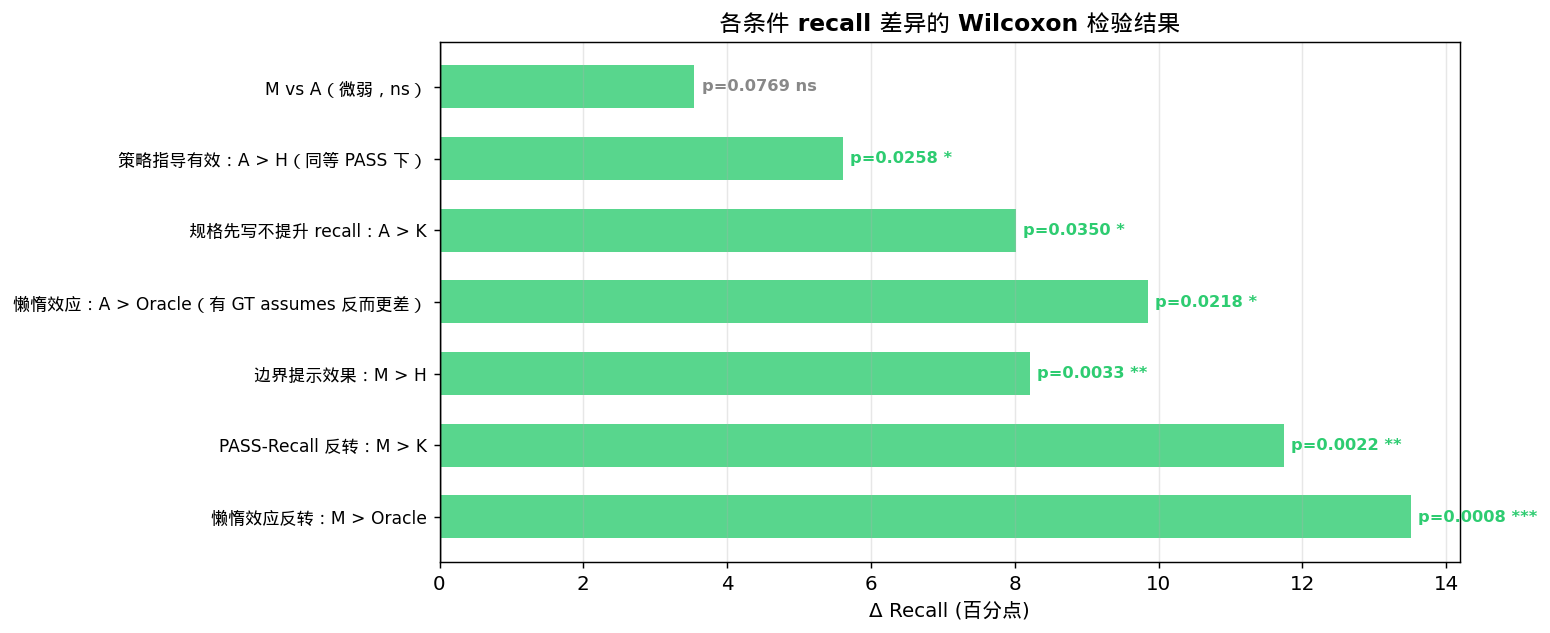

In [14]:
# 可视化统计显著性
fig, ax = plt.subplots(figsize=(12, 5))

labels_plot = [r[0] for r in results_for_plot]
diffs = [r[1] * 100 for r in results_for_plot]  # 转为百分点
pvals = [r[2] for r in results_for_plot]
sigs = [r[3] for r in results_for_plot]

bar_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
alpha_vals = [1.0 if s != 'ns' else 0.4 for s in sigs]

bars = ax.barh(range(len(labels_plot)), diffs, color=bar_colors, alpha=0.8, height=0.6)
ax.set_yticks(range(len(labels_plot)))
ax.set_yticklabels(labels_plot, fontsize=9.5)
ax.set_xlabel('Δ Recall (百分点)', fontsize=11)
ax.set_title('各条件 recall 差异的 Wilcoxon 检验结果', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

for i, (d, p, s) in enumerate(zip(diffs, pvals, sigs)):
    x_pos = d + (0.1 if d >= 0 else -0.1)
    ha = 'left' if d >= 0 else 'right'
    color = '#2ecc71' if s in ['*', '**', '***'] else '#888'
    ax.text(x_pos, i, f'p={p:.4f} {s}', va='center', ha=ha,
            fontsize=9, fontweight='bold', color=color)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## Part 11：Vacuity Check — 我们的结果是真实的吗？

**担心**：K 和 Oracle 的高 PASS 率会不会是「虚假成功」（vacuous success）——即 `__CPROVER_assume` 过于严格，把所有输入都过滤掉了，导致 CBMC 永远不会到达函数调用，从而断言永远不被评估（trivially UNSAT）？

**验证方法**：在函数调用前插入 `__CPROVER_assert(false)`。如果 CBMC 仍然返回 UNSAT，说明函数调用路径不可达 = 真的 vacuous。

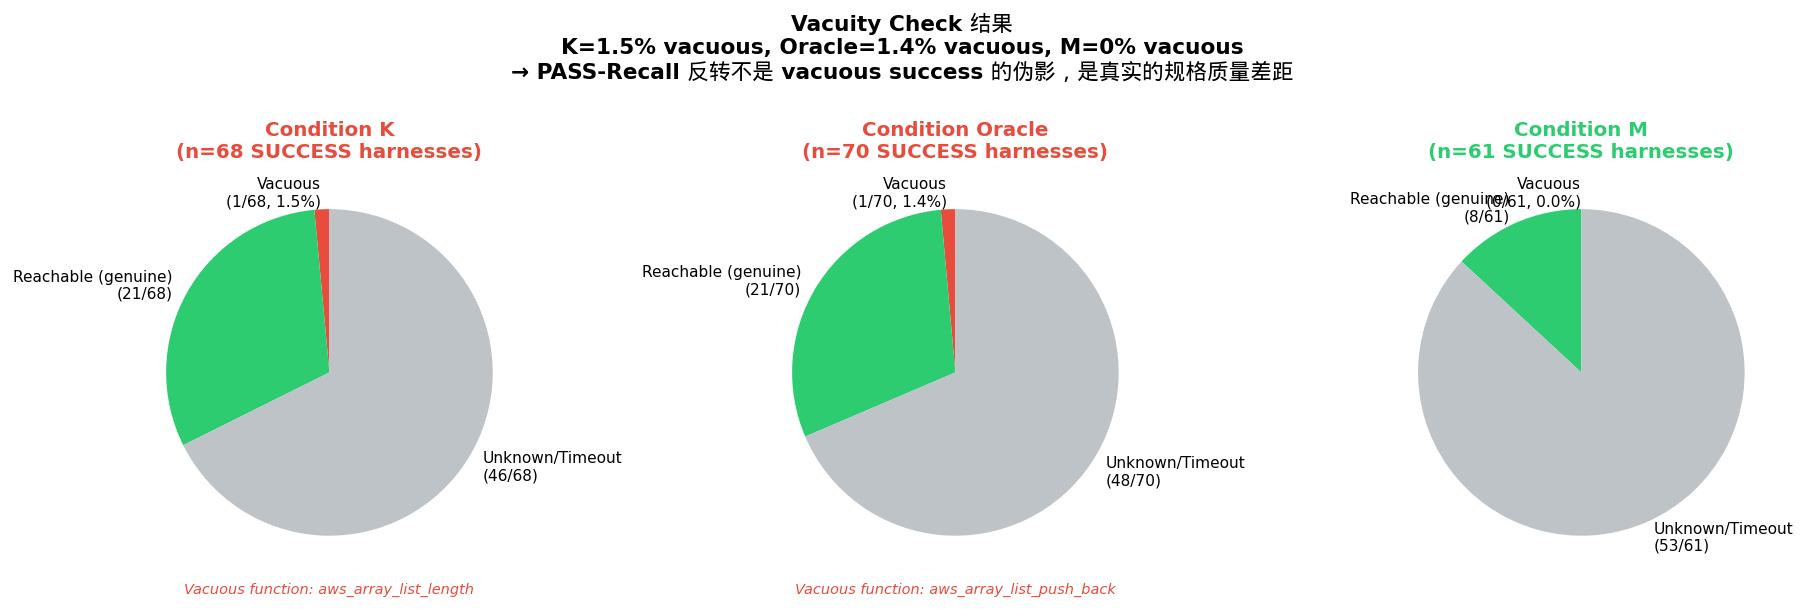

In [15]:
# 读取 vacuity 检验结果
vacuity_summary = {}
for cond in ['K', 'Oracle', 'M']:
    path = os.path.join(EVAL, f'vacuity_check_{cond}_gptoss120b.json')
    with open(path) as f:
        entries = json.load(f)
    total = len(entries)
    vacuous = [e['func'] for e in entries if e['vacuous'] is True]
    reachable = [e['func'] for e in entries if e['vacuous'] is False]
    unknown = [e['func'] for e in entries if e['vacuous'] is None]
    vacuity_summary[cond] = {
        'total': total,
        'vacuous': vacuous,
        'reachable': len(reachable),
        'unknown': len(unknown),
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (cond, data) in zip(axes, vacuity_summary.items()):
    total = data['total']
    sizes = [len(data['vacuous']), data['reachable'], data['unknown']]
    labels_v = [
        f'Vacuous\n({len(data["vacuous"])}/{total}, {100*len(data["vacuous"])/total:.1f}%)',
        f'Reachable (genuine)\n({data["reachable"]}/{total})',
        f'Unknown/Timeout\n({data["unknown"]}/{total})'
    ]
    colors_v = ['#e74c3c', '#2ecc71', '#bdc3c7']
    wedges, texts = ax.pie(sizes, labels=labels_v, colors=colors_v,
                           startangle=90, textprops={'fontsize': 8.5})
    title_color = '#2ecc71' if len(data['vacuous']) == 0 else '#e74c3c'
    ax.set_title(f'Condition {cond}\n(n={total} SUCCESS harnesses)',
                 fontsize=11, fontweight='bold', color=title_color)
    if data['vacuous']:
        ax.text(0, -1.35, f'Vacuous function: {data["vacuous"][0]}',
                ha='center', fontsize=8, color='#e74c3c', style='italic')

fig.suptitle(
    'Vacuity Check 结果\n'
    'K=1.5% vacuous, Oracle=1.4% vacuous, M=0% vacuous\n'
    '→ PASS-Recall 反转不是 vacuous success 的伪影，是真实的规格质量差距',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## Part 12：整体发现总结

研究的故事线：

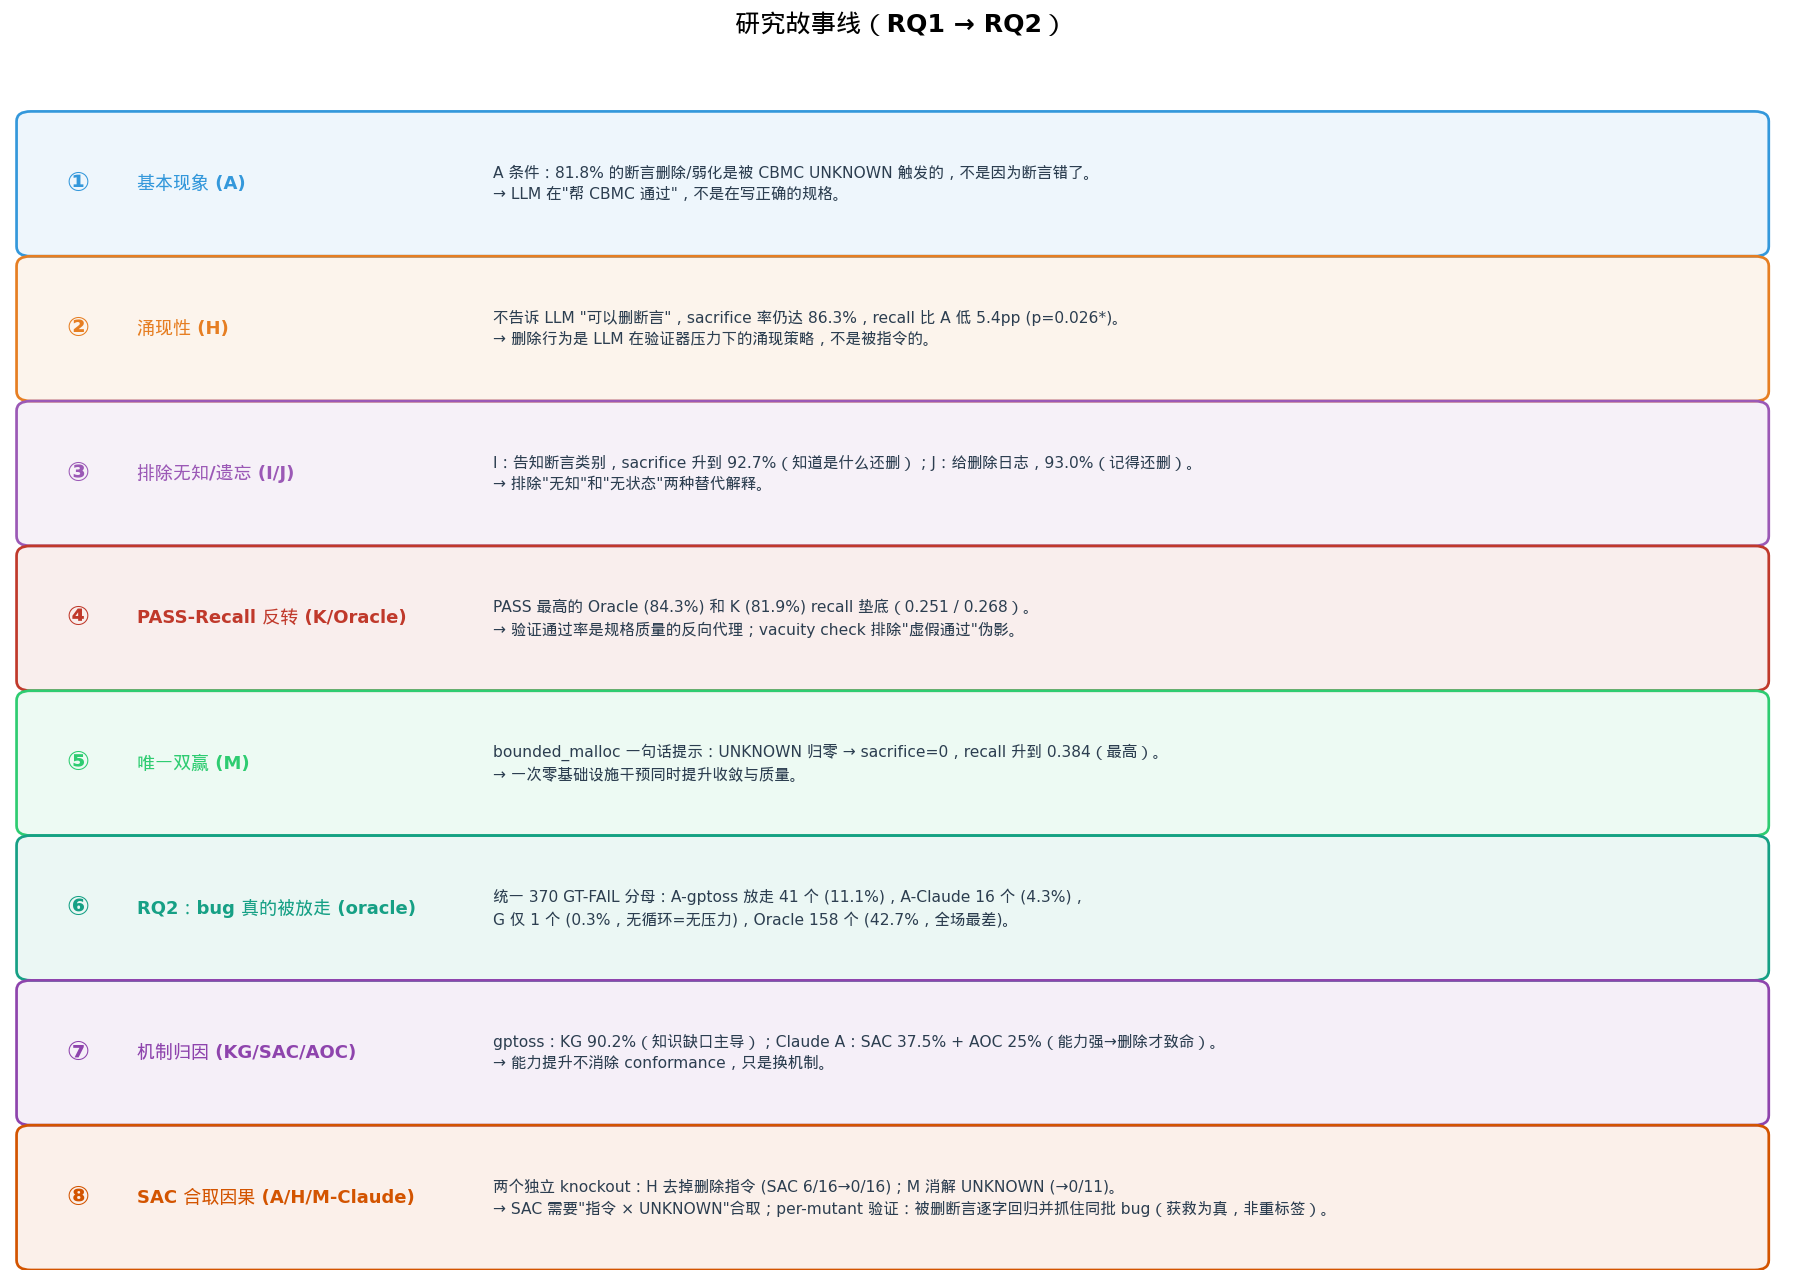

In [16]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

story = [
    ('①', '基本现象 (A)',
     'A 条件：81.8% 的断言删除/弱化是被 CBMC UNKNOWN 触发的，不是因为断言错了。\n'
     '→ LLM 在"帮 CBMC 通过"，不是在写正确的规格。', '#3498db'),
    ('②', '涌现性 (H)',
     '不告诉 LLM "可以删断言"，sacrifice 率仍达 86.3%，recall 比 A 低 5.4pp (p=0.026*)。\n'
     '→ 删除行为是 LLM 在验证器压力下的涌现策略，不是被指令的。', '#e67e22'),
    ('③', '排除无知/遗忘 (I/J)',
     'I：告知断言类别，sacrifice 升到 92.7%（知道是什么还删）；J：给删除日志，93.0%（记得还删）。\n'
     '→ 排除"无知"和"无状态"两种替代解释。', '#9b59b6'),
    ('④', 'PASS-Recall 反转 (K/Oracle)',
     'PASS 最高的 Oracle (84.3%) 和 K (81.9%) recall 垫底（0.251 / 0.268）。\n'
     '→ 验证通过率是规格质量的反向代理；vacuity check 排除"虚假通过"伪影。', '#c0392b'),
    ('⑤', '唯一双赢 (M)',
     'bounded_malloc 一句话提示：UNKNOWN 归零 → sacrifice=0，recall 升到 0.384（最高）。\n'
     '→ 一次零基础设施干预同时提升收敛与质量。', '#2ecc71'),
    ('⑥', 'RQ2：bug 真的被放走 (oracle)',
     '统一 370 GT-FAIL 分母：A-gptoss 放走 41 个 (11.1%)，A-Claude 16 个 (4.3%)，\n'
     'G 仅 1 个 (0.3%，无循环=无压力)，Oracle 158 个 (42.7%，全场最差)。', '#16a085'),
    ('⑦', '机制归因 (KG/SAC/AOC)',
     'gptoss：KG 90.2%（知识缺口主导）；Claude A：SAC 37.5% + AOC 25%（能力强→删除才致命）。\n'
     '→ 能力提升不消除 conformance，只是换机制。', '#8e44ad'),
    ('⑧', 'SAC 合取因果 (A/H/M-Claude)',
     '两个独立 knockout：H 去掉删除指令 (SAC 6/16→0/16)；M 消解 UNKNOWN (→0/11)。\n'
     '→ SAC 需要"指令 × UNKNOWN"合取；per-mutant 验证：被删断言逐字回归并抓住同批 bug（获救为真，非重标签）。', '#d35400'),
]

n = len(story)
row_h = 0.95 / n
for i, (num, title, detail, color) in enumerate(story):
    y = 0.95 - (i + 0.5) * row_h
    ax.add_patch(mpatches.FancyBboxPatch((0.01, y - row_h/2 + 0.008), 0.97, row_h - 0.016,
        boxstyle='round,pad=0.008', linewidth=1.5,
        edgecolor=color, facecolor=color + '15', transform=ax.transAxes))
    ax.text(0.03, y, num, fontsize=15, fontweight='bold', color=color,
            transform=ax.transAxes, va='center')
    ax.text(0.07, y, title, fontsize=10, fontweight='bold', color=color,
            transform=ax.transAxes, va='center')
    ax.text(0.27, y, detail, fontsize=8.6, color='#2c3e50',
            transform=ax.transAxes, va='center', linespacing=1.5)

ax.set_title('研究故事线（RQ1 → RQ2）', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Part 13：RQ2 — Mutation Oracle 结果

> 第二幕证明了"规格有缺口、缺口是涌现的"。但审稿人会问：**缺口 ≠ 事故——漏写的断言真的会放走 bug 吗？**第三幕用形式化证书回答。

RQ1 回答了「LLM 漏掉了什么规格」；**RQ2 回答：漏掉的规格真的会放走 bug 吗？** 每个被放走的 bug 都有形式化证书。

**方法（circularity-free mutation oracle）**：
- 用 universalmutator 注入语法变异（mutant），筛选后得到统一的 **1,233 个有效 mutant**（40 个函数）
- 对每个 mutant 同时跑 GT harness 和 LLM harness（CBMC 5.95.1，配置相同）
- **silenced bug** ⟺ CBMC(GT, m) = FAIL **且** CBMC(LLM, m) = SUCCESS
- 所有条件共享同一个 **GT-FAIL = 370/1233** 分母（逐 mutant 一致，跨 8 条件可比）

**为什么 circularity-free**：我们不声称 GT 是完整规格——只要 GT 抓到了而 LLM 没抓到，被触发的那条 GT 断言就是「这个 bug 被放走了」的有界形式化证书。

**两个 RQ2 指标**：
- **Sil/GT** = silenced / 370 ：被放走的 GT 可检测 bug 比例（越低越好）
- **Oracle recall** = LLM-FAIL / GT-FAIL ：LLM harness 也能抓到的 GT bug 比例（越高越好）

⚠️ 注意与 RQ1 的 assertion recall（Jaccard 文本匹配）区分：oracle recall 是**行为层面**（能否抓到同一个 mutant），assertion recall 是**文本层面**（断言写没写出来）。


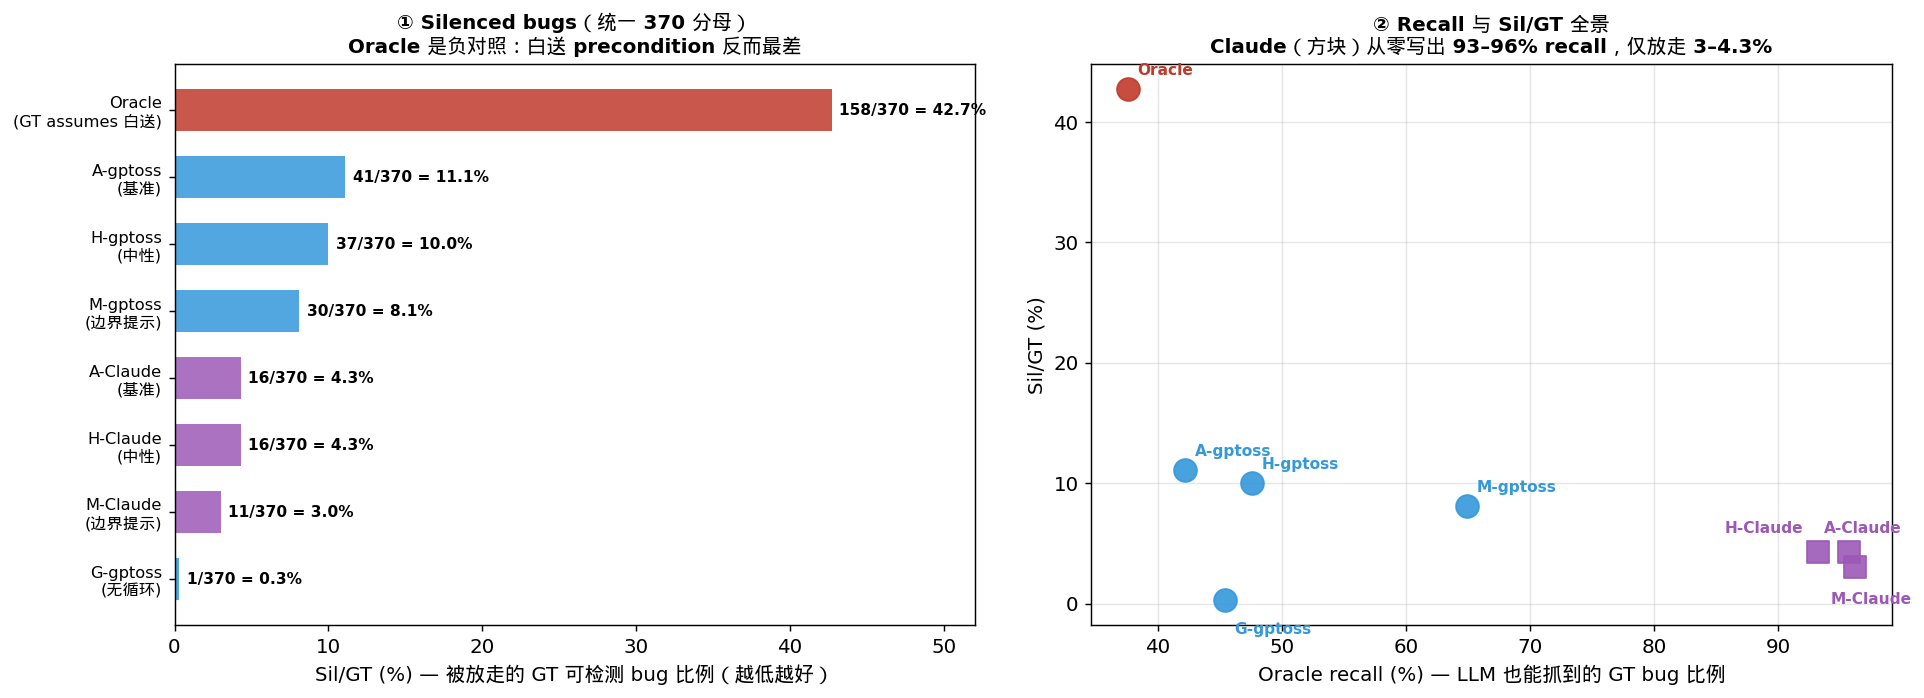

要点：
  1. 反馈循环 critical：G 仅放走 1 个 (0.3%) vs A 41 个 (11.1%) — 但 G 的 recall 也低且 CE 率 61.6%
  2. H ≈ A（10.0% vs 11.1%，p=0.090 单侧 n.s.）：删除指令对安全层面影响不显著（注意：不显著≠等价，见 Part 19）
  3. M 双向改善：gptoss recall 42.2→64.9%，Sil/GT 11.1→8.1%；Claude 95.7→96.2%，4.3→3.0%
  4. Oracle 负对照：158/370 = 42.7%，全场最高 — "白送 precondition" 诱发懒惰而非安全


In [17]:
# RQ2 canonical 数据（paper.tex Table 6 / tab:oracle，统一 370 GT-FAIL 分母）
oracle_rows = [
    # (label, model, silenced, sil_gt %, oracle recall %)
    ('Oracle\n(GT assumes 白送)', 'gptoss', 158, 42.7, 37.6),
    ('A-gptoss\n(基准)',           'gptoss',  41, 11.1, 42.2),
    ('H-gptoss\n(中性)',           'gptoss',  37, 10.0, 47.6),
    ('M-gptoss\n(边界提示)',       'gptoss',  30,  8.1, 64.9),
    ('G-gptoss\n(无循环)',         'gptoss',   1,  0.3, 45.4),
    ('A-Claude\n(基准)',           'claude',  16,  4.3, 95.7),
    ('H-Claude\n(中性)',           'claude',  16,  4.3, 93.2),
    ('M-Claude\n(边界提示)',       'claude',  11,  3.0, 96.2),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左图：Sil/GT 排序
ax = axes[0]
rows_sorted = sorted(oracle_rows, key=lambda r: -r[3])
labels = [r[0] for r in rows_sorted]
vals = [r[3] for r in rows_sorted]
cols = ['#c0392b' if 'Oracle' in r[0] else ('#9b59b6' if r[1]=='claude' else '#3498db')
        for r in rows_sorted]
ax.barh(range(len(labels)), vals, color=cols, alpha=0.85, height=0.62)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Sil/GT (%) — 被放走的 GT 可检测 bug 比例（越低越好）')
for i, (v, r) in enumerate(zip(vals, rows_sorted)):
    ax.text(v + 0.5, i, f'{r[2]}/370 = {v:.1f}%', va='center', fontsize=8.5, fontweight='bold')
ax.set_xlim(0, 52); ax.invert_yaxis()
ax.set_title('① Silenced bugs（统一 370 分母）\nOracle 是负对照：白送 precondition 反而最差',
             fontsize=11, fontweight='bold')

# 右图：oracle recall vs Sil/GT
ax = axes[1]
for label, model, sil, silgt, rec in oracle_rows:
    c = '#c0392b' if 'Oracle' in label else ('#9b59b6' if model=='claude' else '#3498db')
    m = 's' if model == 'claude' else 'o'
    ax.scatter(rec, silgt, s=160, color=c, marker=m, zorder=5, alpha=0.9)
    short = label.split('\n')[0]
    offsets = {'A-Claude': (-2.0, 1.6), 'H-Claude': (-7.5, 1.6), 'M-Claude': (-2.0, -3.0),
               'G-gptoss': (0.8, -2.8)}
    dx, dy = offsets.get(short, (0.8, 1.2))
    ax.annotate(short, xy=(rec, silgt), xytext=(rec + dx, silgt + dy),
                fontsize=8.5, fontweight='bold', color=c)
ax.set_xlabel('Oracle recall (%) — LLM 也能抓到的 GT bug 比例')
ax.set_ylabel('Sil/GT (%)')
ax.set_title('② Recall 与 Sil/GT 全景\nClaude（方块）从零写出 93–96% recall，仅放走 3–4.3%',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('要点：')
print('  1. 反馈循环 critical：G 仅放走 1 个 (0.3%) vs A 41 个 (11.1%) — 但 G 的 recall 也低且 CE 率 61.6%')
print('  2. H ≈ A（10.0% vs 11.1%，p=0.090 单侧 n.s.）：删除指令对安全层面影响不显著（注意：不显著≠等价，见 Part 19）')
print('  3. M 双向改善：gptoss recall 42.2→64.9%，Sil/GT 11.1→8.1%；Claude 95.7→96.2%，4.3→3.0%')
print('  4. Oracle 负对照：158/370 = 42.7%，全场最高 — "白送 precondition" 诱发懒惰而非安全')

### Part 13b：为什么 G 的 silenced 只有 1 个？— verdict 分解（2026-06-11）

Silenced 要求 LLM harness 在带 bug 的代码上**干净返回 SUCCESS**。分解 370 个 GT-FAIL mutant 上的 LLM verdict 发现：G 和 A 抓 bug 能力几乎相同、CE 率也相当——**唯一的区别是反馈循环把 G 的"大声失败"（UNKNOWN/FAIL）一轮轮修成了"无声通过"（SUCCESS）**。G 的 0.3% 是 safety-by-failing-loudly，不是质量高；silencing 是循环制造出来的产物。这也排除了"G 的低 silencing 是幸存者偏差"的解释（CE 率 43.5% vs 40.0%，几乎一样）。


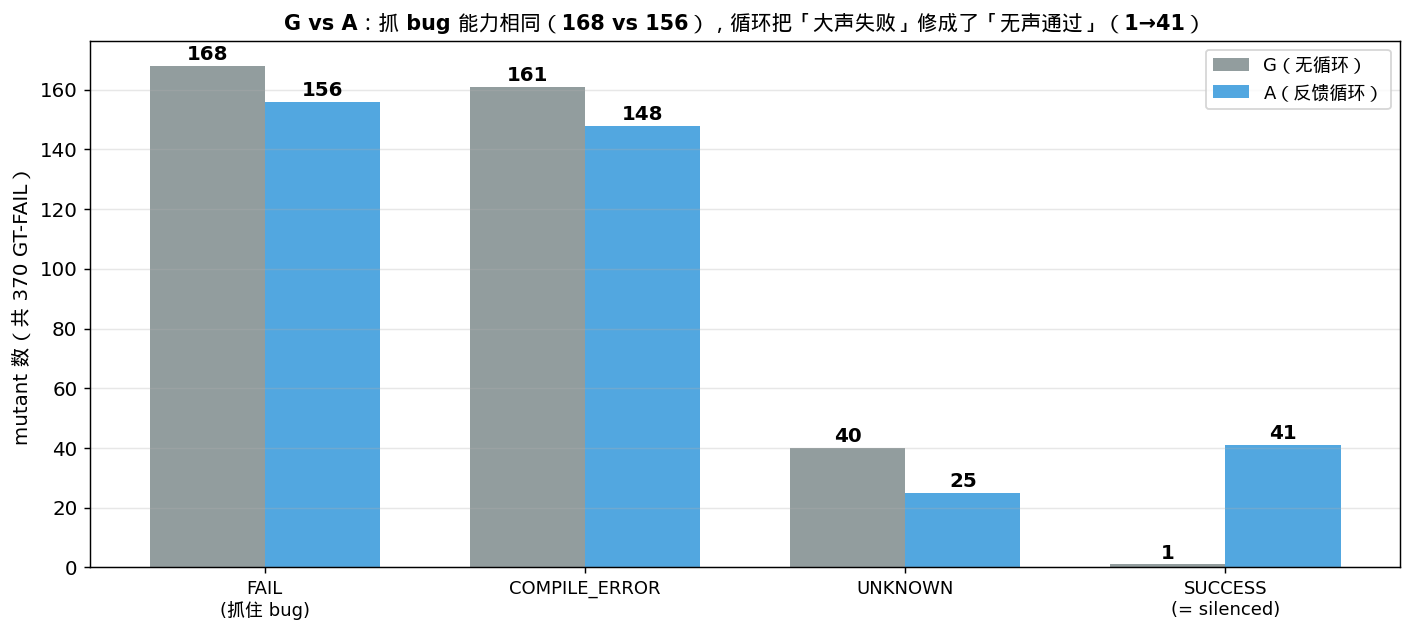

GT 侧 triggered-property 提取（gt_fail_properties_canonical370.json）：
  370/370 verdict 确定性复现；354 个解析出精确触发断言（16 个待修正则）
  来源分解：harness-only 110 / harness+library 132 / library-only 112
  → GT 约 30% 的检测力来自 proof-helper / 库内断言 / libc 模型 precondition，不是 harness 手写 assert


In [18]:
# 370 个 GT-FAIL mutant 上的 LLM verdict 分解（G vs A，gptoss）
verdicts = ['FAIL\n(抓住 bug)', 'COMPILE_ERROR', 'UNKNOWN', 'SUCCESS\n(= silenced)']
G_vals = [168, 161, 40, 1]
A_vals = [156, 148, 25, 41]
colors_v = ['#2ecc71', '#95a5a6', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(verdicts)); w = 0.36
b1 = ax.bar(x - w/2, G_vals, width=w, label='G（无循环）', color='#7f8c8d', alpha=0.85)
b2 = ax.bar(x + w/2, A_vals, width=w, label='A（反馈循环）', color='#3498db', alpha=0.85)
for bars, vals in [(b1, G_vals), (b2, A_vals)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 2, str(v), ha='center', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(verdicts, fontsize=10)
ax.set_ylabel('mutant 数（共 370 GT-FAIL）')
ax.set_title('G vs A：抓 bug 能力相同（168 vs 156），循环把「大声失败」修成了「无声通过」（1→41）',
             fontsize=11.5, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('GT 侧 triggered-property 提取（gt_fail_properties_canonical370.json）：')
print('  370/370 verdict 确定性复现；354 个解析出精确触发断言（16 个待修正则）')
print('  来源分解：harness-only 110 / harness+library 132 / library-only 112')
print('  → GT 约 30% 的检测力来自 proof-helper / 库内断言 / libc 模型 precondition，不是 harness 手写 assert')

---
## Part 14：三机制归因 — 同样是漏 bug，gptoss 和 Claude 走的路完全不同

每个 silenced bug 通过**自动断言追踪**（跨迭代 diff）+ **AOC 检测器**（assume-envelope 对比）归因到：

- **KG**（knowledge gap）：对应断言在任何迭代中都没出现过 → 不知道要写
- **SAC**（assertion sacrifice）：写出过正确断言，在 UNKNOWN 后删掉 → 知道但放弃（主动 conformance）
- **AOC**（assumption over-constraint）：断言都在，但 `__CPROVER_assume(x ≤ bound)` 把 bug 所在状态切掉了（被动 conformance）


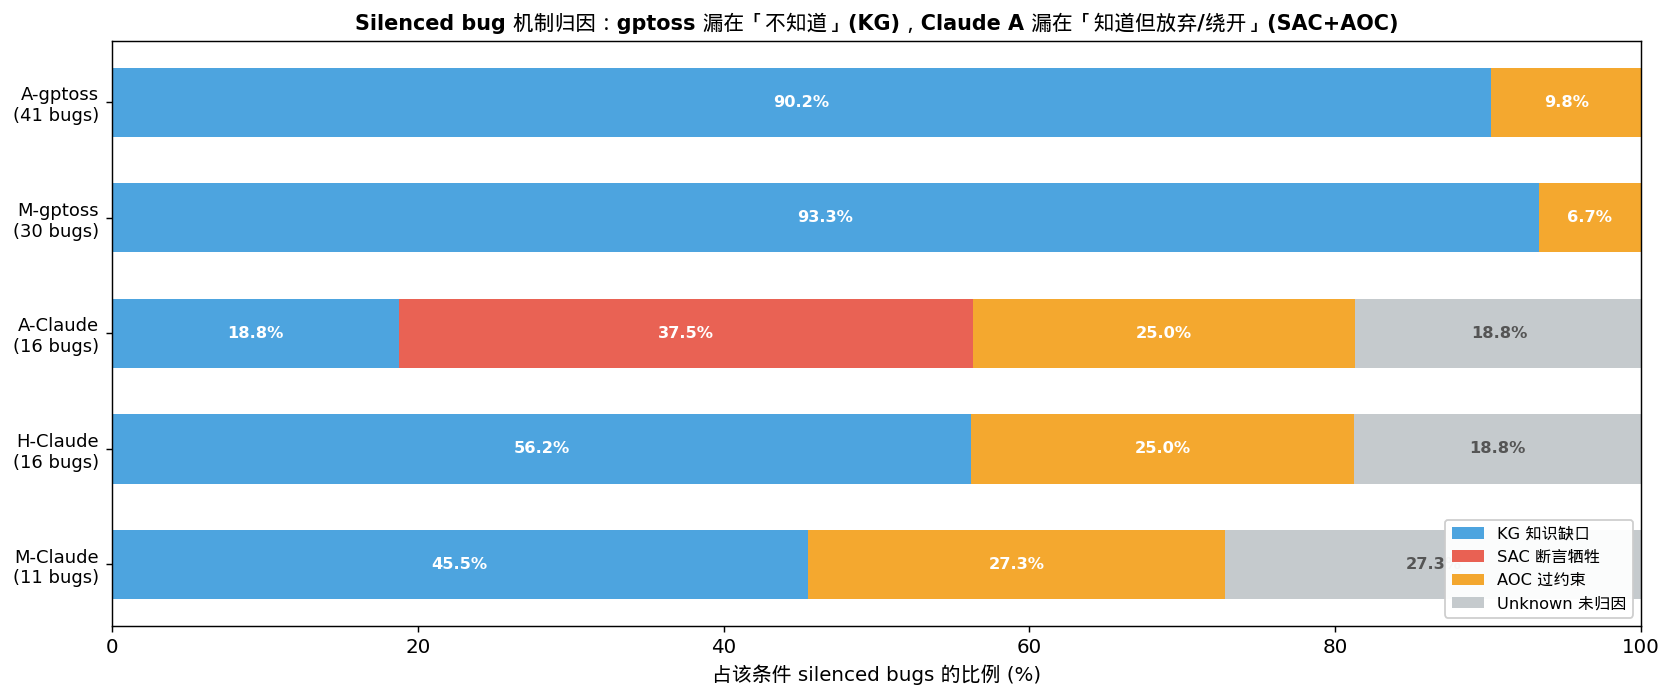

解读：
  - gptoss：KG 90%+，SAC=0 — 删掉的断言本来也抓不到 mutant，漏 bug 是知识问题
  - Claude A：SAC 37.5% (6/16) + AOC 25% — 能力强 → 写得出正确断言 → 删除才有安全代价
  - H-Claude / M-Claude：SAC 都归零（这是 Part 15 合取因果发现的数据基础）
  - ⚠️ 注意 H-Claude 总数仍是 16：SAC 归零但 KG 从 3 升到 9（评审质疑点，见 Part 19）


In [19]:
# 归因数据（paper.tex Table 7 / tab:attribution）
attr_rows = [
    ('A-gptoss\n(41 bugs)',  90.2,  0.0,  9.8,  0.0),
    ('M-gptoss\n(30 bugs)',  93.3,  0.0,  6.7,  0.0),
    ('A-Claude\n(16 bugs)',  18.8, 37.5, 25.0, 18.8),
    ('H-Claude\n(16 bugs)',  56.2,  0.0, 25.0, 18.8),
    ('M-Claude\n(11 bugs)',  45.5,  0.0, 27.3, 27.3),
]
mech_names  = ['KG 知识缺口', 'SAC 断言牺牲', 'AOC 过约束', 'Unknown 未归因']
mech_colors = ['#3498db', '#e74c3c', '#f39c12', '#bdc3c7']

fig, ax = plt.subplots(figsize=(13, 5.5))
labels = [r[0] for r in attr_rows]
y = np.arange(len(labels))
left = np.zeros(len(labels))
for k, (mn, mc) in enumerate(zip(mech_names, mech_colors)):
    vals = np.array([r[k+1] for r in attr_rows])
    ax.barh(y, vals, left=left, color=mc, alpha=0.88, height=0.6, label=mn)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 6:
            ax.text(l + v/2, i, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if k != 3 else '#555')
    left += vals
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('占该条件 silenced bugs 的比例 (%)')
ax.set_xlim(0, 100); ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax.set_title('Silenced bug 机制归因：gptoss 漏在「不知道」(KG)，Claude A 漏在「知道但放弃/绕开」(SAC+AOC)',
             fontsize=11.5, fontweight='bold')
plt.tight_layout()
plt.show()

print('解读：')
print('  - gptoss：KG 90%+，SAC=0 — 删掉的断言本来也抓不到 mutant，漏 bug 是知识问题')
print('  - Claude A：SAC 37.5% (6/16) + AOC 25% — 能力强 → 写得出正确断言 → 删除才有安全代价')
print('  - H-Claude / M-Claude：SAC 都归零（这是 Part 15 合取因果发现的数据基础）')
print('  - ⚠️ 注意 H-Claude 总数仍是 16：SAC 归零但 KG 从 3 升到 9（评审质疑点，见 Part 19）')

---
## Part 15：SAC 合取因果 — 论文的头条发现（及其边界）

**问题**：是什么驱动了 SAC？是「prompt 允许删除」还是「CBMC UNKNOWN 压力」？

**设计**：A/H/M（Claude）构成 2×2 因子设计中的三个格子，每个 knockout 只去掉一个因素：

| | 有删除指令 | 无删除指令 |
|---|---|---|
| **UNKNOWN 未消解** | **A：SAC = 6/16 = 37.5%** | **H：SAC = 0/16** |
| **UNKNOWN 已消解 (M)** | **M：SAC = 0/11** | （未测量） |

**结论**：去掉任一因素 SAC 都归零 → SAC 需要两个因素的**合取**（conjunction）。

**诚实的边界（已写进 Limitations，也是评审的主要攻击点）**：
1. 仅 Claude（gptoss 所有条件 SAC=0%，没有 SAC 可分解）；n 很小（6/16 → 0/16、0/11）
2. 第四个格子（无指令 + 无 UNKNOWN）未测量
3. ~~机制替换质疑（DA-CRITICAL）~~ **已用 per-mutant 数据驳回（2026-06-11，见 Part 15b）**：A 的 SAC bug 在 H/M 下是真实获救（被删断言逐字回归并抓住同一批 mutant），0 个被重标为 KG；H 总数 16→16 是因为 H 从零生成的 byte_buf_cat harness 较弱（生成方差），在别处新丢 8 个——SAC 合取与"H 安全层面无差异"两个结论同时为真


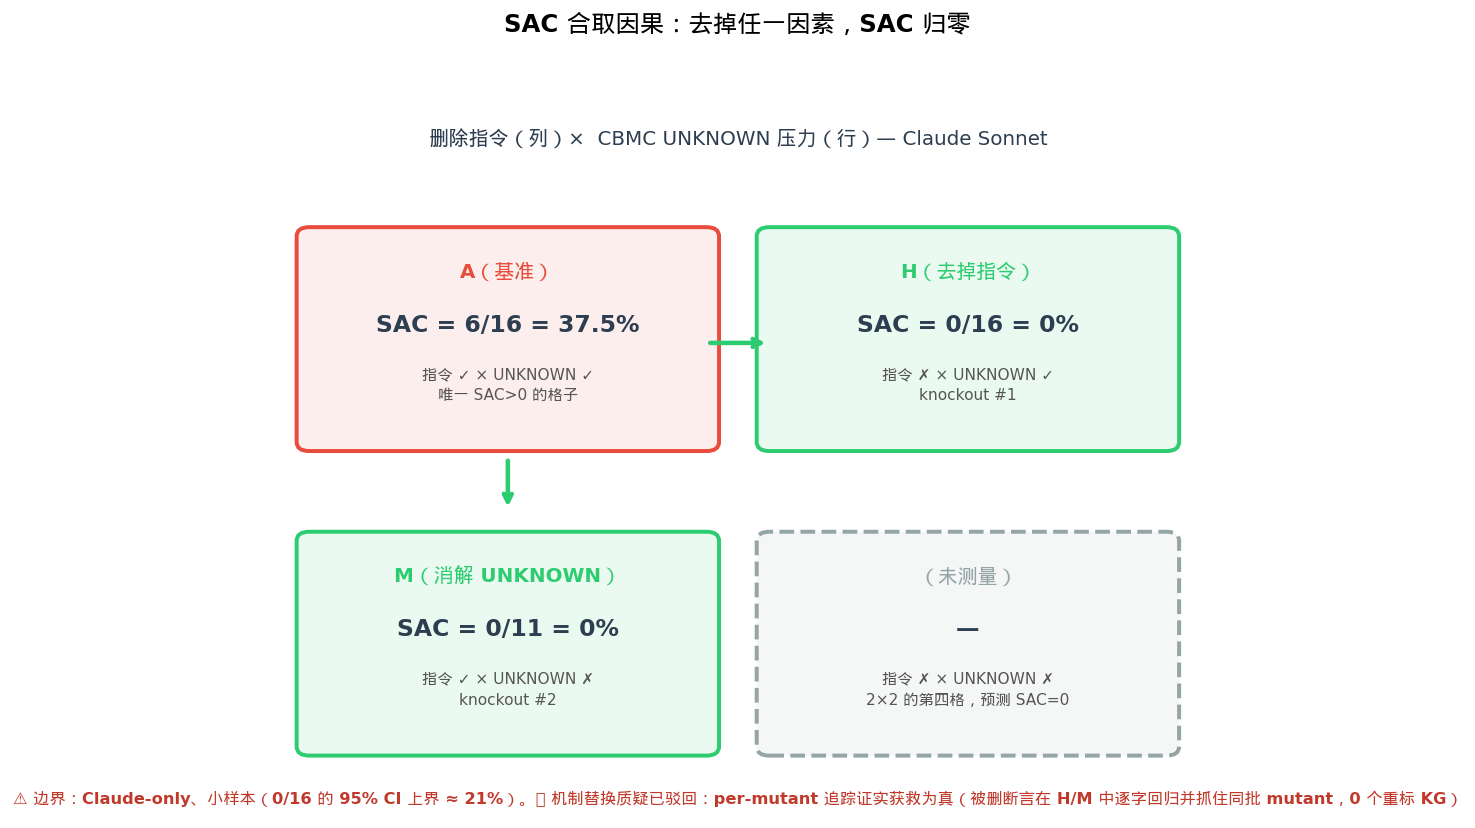

In [20]:
# 2x2 合取因果图
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.axis('off')

cells_2x2 = [
    # (x, y, title, value, color, note)
    (0.28, 0.62, 'A（基准）', 'SAC = 6/16 = 37.5%', '#e74c3c', '指令 ✓ × UNKNOWN ✓\n唯一 SAC>0 的格子'),
    (0.72, 0.62, 'H（去掉指令）', 'SAC = 0/16 = 0%', '#2ecc71', '指令 ✗ × UNKNOWN ✓\nknockout #1'),
    (0.28, 0.22, 'M（消解 UNKNOWN）', 'SAC = 0/11 = 0%', '#2ecc71', '指令 ✓ × UNKNOWN ✗\nknockout #2'),
    (0.72, 0.22, '（未测量）', '—', '#95a5a6', '指令 ✗ × UNKNOWN ✗\n2×2 的第四格，预测 SAC=0'),
]
for x, y, title, val, color, note in cells_2x2:
    ls = 'dashed' if '未测量' in title else 'solid'
    ax.add_patch(mpatches.FancyBboxPatch((x-0.19, y-0.13), 0.38, 0.27,
        boxstyle='round,pad=0.012', linewidth=2.2, linestyle=ls,
        edgecolor=color, facecolor=color + '18', transform=ax.transAxes))
    ax.text(x, y+0.085, title, ha='center', fontsize=11, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(x, y+0.015, val, ha='center', fontsize=13, fontweight='bold',
            color='#2c3e50', transform=ax.transAxes)
    ax.text(x, y-0.075, note, ha='center', fontsize=8.5, color='#555',
            transform=ax.transAxes, linespacing=1.5)

ax.text(0.5, 0.88, '删除指令（列）×  CBMC UNKNOWN 压力（行）— Claude Sonnet',
        ha='center', fontsize=11, color='#2c3e50', transform=ax.transAxes)
ax.annotate('', xy=(0.53, 0.62), xytext=(0.47, 0.62),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))
ax.annotate('', xy=(0.28, 0.40), xytext=(0.28, 0.47),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))

ax.text(0.5, 0.015,
        '⚠️ 边界：Claude-only、小样本（0/16 的 95% CI 上界 ≈ 21%）。'
        '✅ 机制替换质疑已驳回：per-mutant 追踪证实获救为真（被删断言在 H/M 中逐字回归并抓住同批 mutant，0 个重标 KG）',
        ha='center', fontsize=9, color='#c0392b', fontweight='bold',
        transform=ax.transAxes)
ax.set_title('SAC 合取因果：去掉任一因素，SAC 归零', fontsize=13.5, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Part 15b：Per-mutant rescue 验证 — 机制替换质疑的数据回应（2026-06-11）

**质疑（模拟评审 DA-CRITICAL）**："SAC→0 可能只是记账：同一断言在 A 下'先写后删'算 SAC，在 H 下'从未写出'算 KG——bug 一个没少，只是换了标签。"

**验证方法**：把 A-Claude 的 16 个 silenced mutant 逐个在 H/M 的 oracle 结果里查命运，并 diff 最终 harness 的断言集合。

**结论**：
1. **获救是真实的**：A 删掉的 `assert(buf.len == 0)`（secure_zero 的 SAC 断言）在 H 和 M 的最终 harness 里**逐字存在**，对应的 4 个 mutant 在两个 knockout 下都被抓住（FAIL）；ring_buffer 的 2 个变为 COMPILE_ERROR（大声失败）。**0 个 SAC bug 被重标为 KG**。
2. **H 总数 16→16 的真相**：H 救回 8 个，但从零生成的 `aws_byte_buf_cat` harness 较弱（11 vs A 的 13 条断言，缺 2 条 frame condition 和 error-path 检查），新丢 6 个 KG + 2 个 AOC——这是**单次生成方差**，不是标签转移。
3. **一石二鸟**：这同时化解了"自相矛盾"指控——SAC 合取（机制层）与 H≈A（安全总量层）**同时为真**，因为 SAC 只是三条通道之一；合取决定**哪个机制**起作用，生成方差决定**哪些 bug**被放走。M 救 8 丢 3（净 −5），仍是唯一净改善干预。


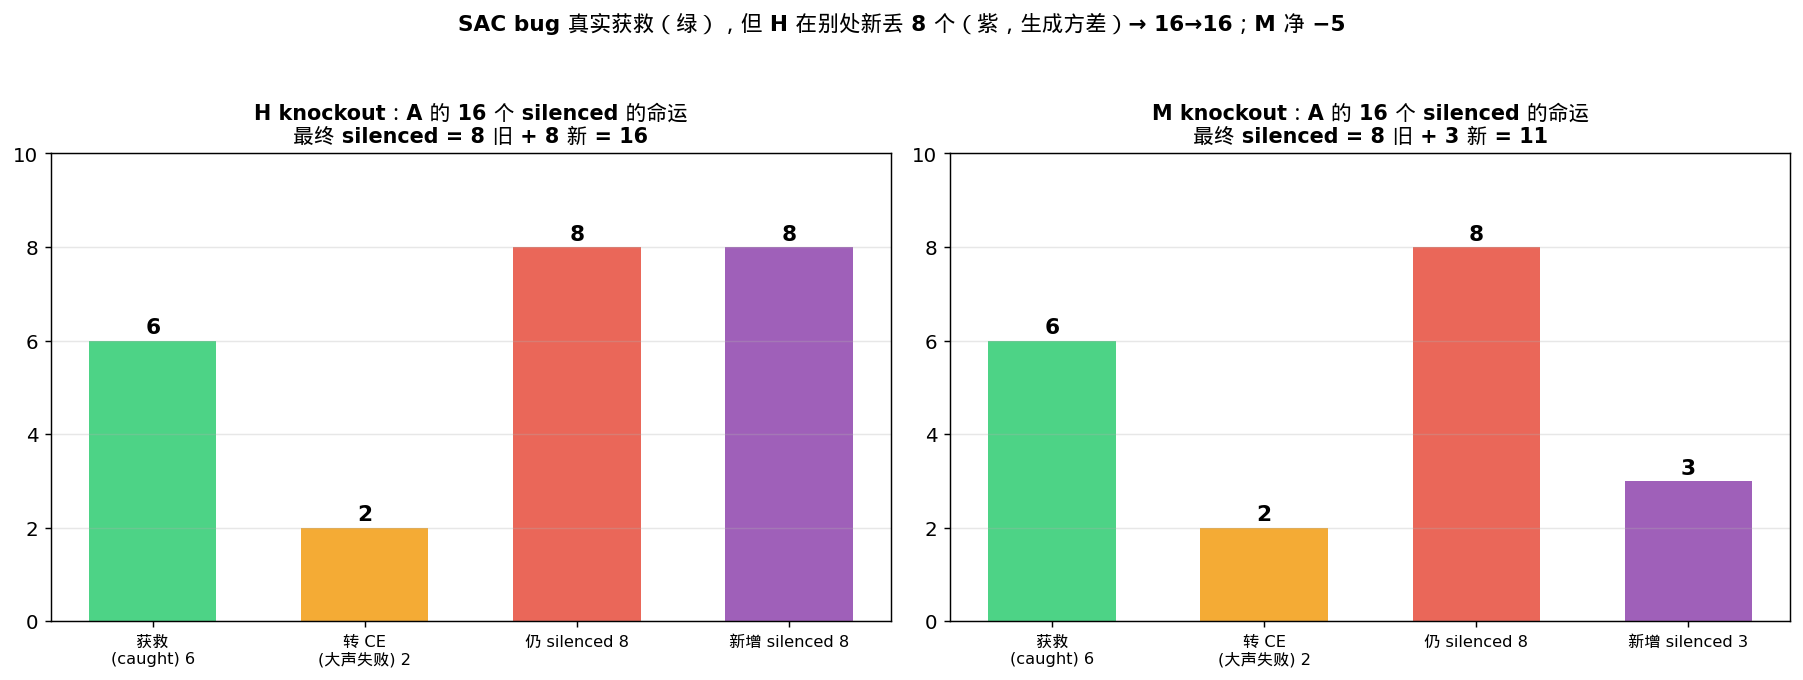

烟枪证据：A 删掉的 assert(buf.len == 0) 在 H 和 M 的最终 harness 中逐字存在，
         对应 4 个 secure_zero mutant 在两个 knockout 下均为 FAIL（抓住）。
byte_buf_cat 断言集 diff：A=13 条 vs H=11 条（H 缺 src2 frame condition + error-path 断言）
→ H 新丢的 6 个 KG 是「从零生成了较弱的 harness」（方差），不是 SAC 的重新标签。


In [21]:
# A-Claude 16 个 silenced bug 在 H / M 下的逐组命运（服务器 per-mutant 分析，2026-06-11）
fate_rows = [
    # (函数组, A归因, H下命运, M下命运)
    ('secure_zero ×4',        'SAC',     'caught',   'caught'),
    ('ring_buffer ×2',        'SAC',     'CE',       'CE'),
    ('from_array ×2',         'AOC',     'caught',   'caught'),
    ('from_empty_array ×2',   'AOC',     'silenced', 'silenced'),
    ('byte_buf_cat ×3',       'KG',      'silenced', 'silenced'),
    ('byte_buf_reset ×3',     'Unknown', 'silenced', 'silenced'),
]
new_silenced = {'H': 8, 'M': 3}  # knockout 下新增的 silenced（A 下原本抓住）

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_colors = {'caught': '#2ecc71', 'CE': '#f39c12', 'silenced': '#e74c3c'}

for ax, cond in zip(axes, ['H', 'M']):
    col = 2 if cond == 'H' else 3
    cats = {'caught': 0, 'CE': 0, 'silenced': 0}
    for row in fate_rows:
        n = int(row[0].split('×')[1])
        cats[row[col]] += n
    labels = [f'获救\n(caught) {cats["caught"]}', f'转 CE\n(大声失败) {cats["CE"]}',
              f'仍 silenced {cats["silenced"]}', f'新增 silenced {new_silenced[cond]}']
    vals = [cats['caught'], cats['CE'], cats['silenced'], new_silenced[cond]]
    colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, str(v), ha='center',
                fontweight='bold', fontsize=12)
    total = cats['caught'] + cats['CE'] + cats['silenced']
    net = cats['silenced'] + new_silenced[cond]
    ax.set_title(f'{cond} knockout：A 的 16 个 silenced 的命运\n'
                 f'最终 silenced = {cats["silenced"]} 旧 + {new_silenced[cond]} 新 = {net}',
                 fontsize=11.5, fontweight='bold')
    ax.set_ylim(0, 10); ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('SAC bug 真实获救（绿），但 H 在别处新丢 8 个（紫，生成方差）→ 16→16；M 净 −5',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print('烟枪证据：A 删掉的 assert(buf.len == 0) 在 H 和 M 的最终 harness 中逐字存在，')
print('         对应 4 个 secure_zero mutant 在两个 knockout 下均为 FAIL（抓住）。')
print('byte_buf_cat 断言集 diff：A=13 条 vs H=11 条（H 缺 src2 frame condition + error-path 断言）')
print('→ H 新丢的 6 个 KG 是「从零生成了较弱的 harness」（方差），不是 SAC 的重新标签。')

---
## Part 16：跨模型复现 — Llama 3.3 70B（A/G/H）

目的：确认 sacrifice 不是 gpt-oss-120b 特有的伪影。Llama 跑了三个 sacrifice 测量条件（A/G/H），指标为 RQ1 的 pass/recall/sacrifice ratio（无 oracle/silencing 数据——评审已指出应在「replication」措辞处说明这一点）。


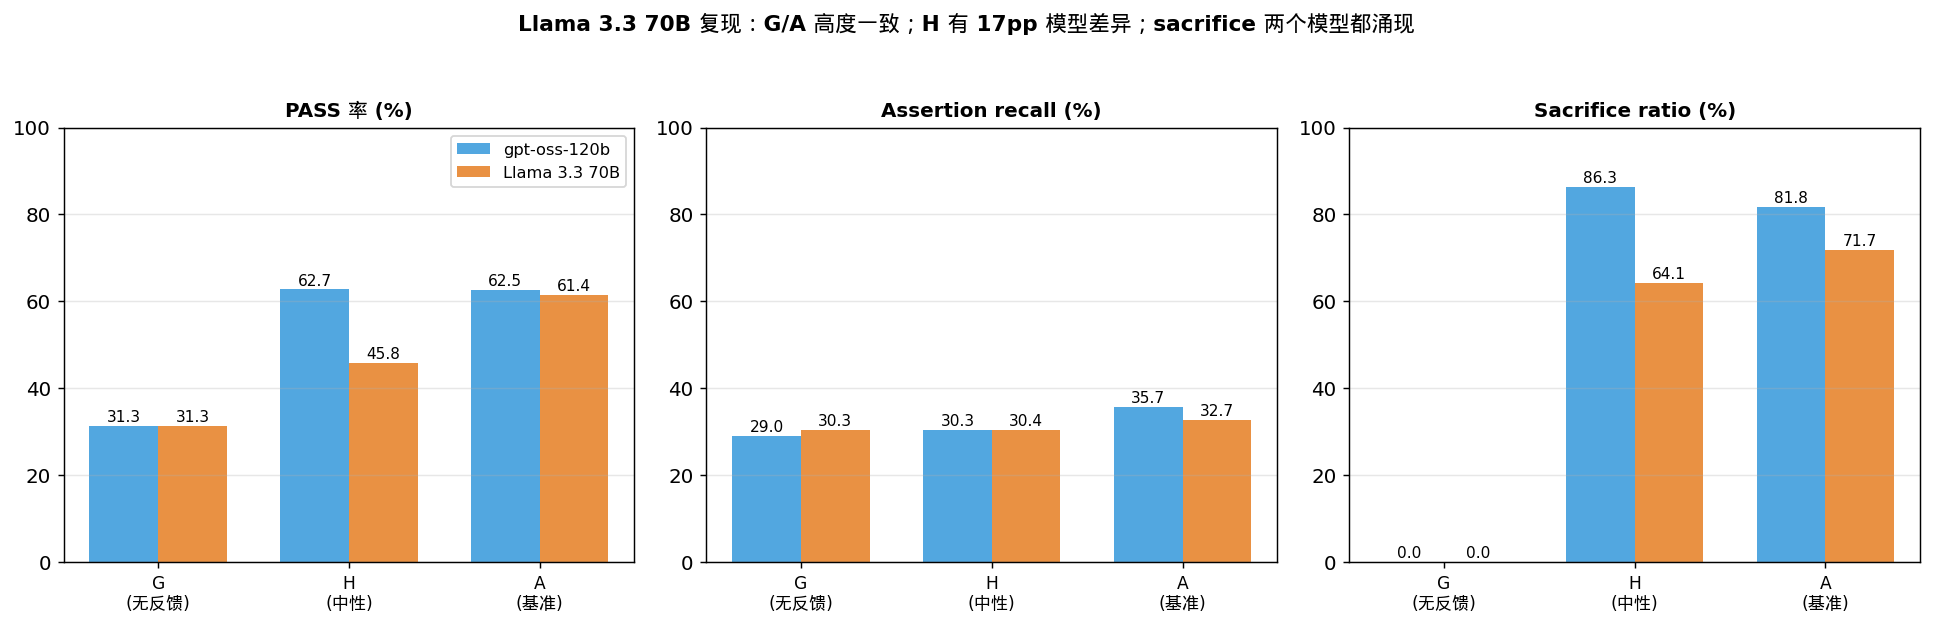

复现了什么：反馈循环 critical（G≈31% vs A≈62%）；sacrifice 跨模型涌现（H 64-86%，无指令照删）
差异：Llama 的 H pass 低 17pp（更保守的修复策略，更多 predicate weakening）
局限：Llama 无 mutation oracle 数据 → "replication" 仅覆盖 RQ1 指标


In [22]:
# Llama 复现数据（paper.tex Table 8 / tab:llama）
conds = ['G\n(无反馈)', 'H\n(中性)', 'A\n(基准)']
gptoss = {'pass': [31.3, 62.7, 62.5], 'recall': [29.0, 30.3, 35.7], 'sac': [0, 86.3, 81.8]}
llama  = {'pass': [31.3, 45.8, 61.4], 'recall': [30.3, 30.4, 32.7], 'sac': [0, 64.1, 71.7]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
metrics = [('pass', 'PASS 率 (%)'), ('recall', 'Assertion recall (%)'), ('sac', 'Sacrifice ratio (%)')]
x = np.arange(len(conds)); w = 0.36
for ax, (key, title) in zip(axes, metrics):
    ax.bar(x - w/2, gptoss[key], width=w, label='gpt-oss-120b', color='#3498db', alpha=0.85)
    ax.bar(x + w/2, llama[key],  width=w, label='Llama 3.3 70B', color='#e67e22', alpha=0.85)
    for i in range(len(conds)):
        ax.text(i - w/2, gptoss[key][i] + 1, f'{gptoss[key][i]:.1f}', ha='center', fontsize=8.5)
        ax.text(i + w/2, llama[key][i] + 1,  f'{llama[key][i]:.1f}',  ha='center', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 100); ax.grid(True, alpha=0.3, axis='y')
axes[0].legend(fontsize=9)
fig.suptitle('Llama 3.3 70B 复现：G/A 高度一致；H 有 17pp 模型差异；sacrifice 两个模型都涌现',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print('复现了什么：反馈循环 critical（G≈31% vs A≈62%）；sacrifice 跨模型涌现（H 64-86%，无指令照删）')
print('差异：Llama 的 H pass 低 17pp（更保守的修复策略，更多 predicate weakening）')
print('局限：Llama 无 mutation oracle 数据 → "replication" 仅覆盖 RQ1 指标')

---
## Part 17：实验全景表 — 每个实验对应哪个 RQ、用什么 metric、排除/证明了什么


In [23]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

rows = [
 # 条件, 模型, 相对A的唯一变量, RQ, 主要metrics, 关键结果, 结论（证明/排除了什么）
 ('A',      'gptoss/Claude/Llama', '—（基准：迭代反馈+允许删除）', 'RQ1+RQ2',
  'pass/recall/sacrifice; Sil/GT/oracle recall/归因',
  'gptoss: 62.5%/0.357/81.8%; 41 silenced (11.1%); Claude: 16 (4.3%, SAC 37.5%)',
  '基准：conformance 现象的存在性与规模'),
 ('G',      'gptoss/Llama', '去掉反馈循环（单次生成）', 'RQ1+RQ2',
  'pass/recall; Sil/GT',
  '31.3%/0.290; 1 silenced (0.3%)（CE 61.6%，分母为可运行对）',
  '反馈循环是 conformance 压力的来源（无循环→几乎无 silencing，但收敛也差）'),
 ('H',      'gptoss/Claude/Llama', '去掉"允许删除"指令（策略中性）', 'RQ1+RQ2',
  'sacrifice; 删除事件 Wilcoxon; Sil/GT; SAC 归因',
  'sacrifice 86.3%; 删除 A>H p=0.014; Sil/GT 10.0≈11.1% p=0.090 n.s.; Claude SAC 0/16',
  '① sacrifice 是涌现的不是被指令的；② SAC 合取 knockout #1（去指令→SAC=0）'),
 ('I',      'gptoss', '每次 UNKNOWN 注入 GT 断言类别标签', 'RQ1',
  'sacrifice; deletion scope',
  'sacrifice 92.7%（升）; scope 6.7→5.5',
  '排除"无知"解释：知道断言类别照样删，删得更准'),
 ('J',      'gptoss', '附加历史删除日志', 'RQ1',
  'sacrifice; recall',
  'sacrifice 93.0%; J>H recall p=0.006**',
  '排除"无状态/遗忘"解释：记得也删；上下文只起次要保护作用'),
 ('K',      'gptoss', '先写 NL 合约再翻译为断言（spec-first）', 'RQ1',
  'pass/recall/sacrifice/over-constraint/vacuity',
  '81.9% pass / 0.268 recall / sacrifice 25% / 过约束 31.3%',
  '高 pass 低 recall 的第二个实例；NL 合约不完整+引入过约束；删除变精准(80% targeted)'),
 ('M',      'gptoss/Claude', '初始 prompt 加 bounded_malloc 一句话', 'RQ1+RQ2',
  '全部 RQ1 指标 + Sil/GT/oracle recall/SAC 归因',
  'gptoss: UNKNOWN 归零, sacrifice 0%, recall 0.384, oracle recall 42.2→64.9%, Sil/GT 8.1%; Claude SAC 0/11',
  '① 唯一双赢干预（零基础设施）；② SAC 合取 knockout #2（消解 UNKNOWN→SAC=0）'),
 ('Oracle', 'gptoss', '白送 GT 的 __CPROVER_assume preconditions', 'RQ1+RQ2',
  'pass/recall/vacuity; Sil/GT',
  '84.3% pass（最高）/ 0.251 recall（最低）/ 158 silenced = 42.7%（最高）',
  '负对照：去掉 setup 难题后 conformance 压力被隔离 → 懒惰效应；"给答案"不等于更安全'),
 ('Llama A/G/H', 'Llama 3.3 70B', '换模型复现 sacrifice 三条件', '复现',
  'pass/recall/sacrifice（无 oracle）',
  'G/A 复现 (<2pp)；H 差 17pp；sacrifice 64-72%',
  'sacrifice 跨模型涌现，非 gptoss 特有'),
 ('Vacuity check', 'gptoss', '函数调用前插 assert(false) 验证可达性', 'RQ1 效度',
  'vacuous 比例',
  'K 1/68, Oracle 1/70, M 0 vacuous',
  '排除"高 pass 是虚假通过"的伪影解释'),
 ('Cloze test', '—', '挖掉 GT 单条断言让 LLM 填空', 'RQ2 后续',
  '填空成功率（按 KG 类别）',
  '（待跑，脚本就绪）',
  '区分 KG 是 placement failure 还是 knowledge failure'),
 ('s2n-tls', '—', '换语料库（协议代码）', '外部效度',
  '同 RQ1/RQ2',
  '（待跑，任务 #20）',
  '检验结论是否超出 buffer-centric 数据结构代码'),
]

df = pd.DataFrame(rows, columns=['实验/条件', '模型', '相对 A 的唯一变量', '对应 RQ',
                                  '主要 metrics', '关键结果', '证明/排除了什么'])
from IPython.display import HTML
HTML(df.to_html(index=False).replace('<th>', '<th style="text-align:left;background:#2c3e50;color:white">')
                            .replace('<td>', '<td style="text-align:left;vertical-align:top">'))

实验/条件,模型,相对 A 的唯一变量,对应 RQ,主要 metrics,关键结果,证明/排除了什么
A,gptoss/Claude/Llama,—（基准：迭代反馈+允许删除）,RQ1+RQ2,pass/recall/sacrifice; Sil/GT/oracle recall/归因,"gptoss: 62.5%/0.357/81.8%; 41 silenced (11.1%); Claude: 16 (4.3%, SAC 37.5%)",基准：conformance 现象的存在性与规模
G,gptoss/Llama,去掉反馈循环（单次生成）,RQ1+RQ2,pass/recall; Sil/GT,31.3%/0.290; 1 silenced (0.3%)（CE 61.6%，分母为可运行对）,反馈循环是 conformance 压力的来源（无循环→几乎无 silencing，但收敛也差）
H,gptoss/Claude/Llama,"去掉""允许删除""指令（策略中性）",RQ1+RQ2,sacrifice; 删除事件 Wilcoxon; Sil/GT; SAC 归因,sacrifice 86.3%; 删除 A>H p=0.014; Sil/GT 10.0≈11.1% p=0.090 n.s.; Claude SAC 0/16,① sacrifice 是涌现的不是被指令的；② SAC 合取 knockout #1（去指令→SAC=0）
I,gptoss,每次 UNKNOWN 注入 GT 断言类别标签,RQ1,sacrifice; deletion scope,sacrifice 92.7%（升）; scope 6.7→5.5,"排除""无知""解释：知道断言类别照样删，删得更准"
J,gptoss,附加历史删除日志,RQ1,sacrifice; recall,sacrifice 93.0%; J>H recall p=0.006**,"排除""无状态/遗忘""解释：记得也删；上下文只起次要保护作用"
K,gptoss,先写 NL 合约再翻译为断言（spec-first）,RQ1,pass/recall/sacrifice/over-constraint/vacuity,81.9% pass / 0.268 recall / sacrifice 25% / 过约束 31.3%,高 pass 低 recall 的第二个实例；NL 合约不完整+引入过约束；删除变精准(80% targeted)
M,gptoss/Claude,初始 prompt 加 bounded_malloc 一句话,RQ1+RQ2,全部 RQ1 指标 + Sil/GT/oracle recall/SAC 归因,"gptoss: UNKNOWN 归零, sacrifice 0%, recall 0.384, oracle recall 42.2→64.9%, Sil/GT 8.1%; Claude SAC 0/11",① 唯一双赢干预（零基础设施）；② SAC 合取 knockout #2（消解 UNKNOWN→SAC=0）
Oracle,gptoss,白送 GT 的 __CPROVER_assume preconditions,RQ1+RQ2,pass/recall/vacuity; Sil/GT,84.3% pass（最高）/ 0.251 recall（最低）/ 158 silenced = 42.7%（最高）,"负对照：去掉 setup 难题后 conformance 压力被隔离 → 懒惰效应；""给答案""不等于更安全"
Llama A/G/H,Llama 3.3 70B,换模型复现 sacrifice 三条件,复现,pass/recall/sacrifice（无 oracle）,G/A 复现 (<2pp)；H 差 17pp；sacrifice 64-72%,sacrifice 跨模型涌现，非 gptoss 特有
Vacuity check,gptoss,函数调用前插 assert(false) 验证可达性,RQ1 效度,vacuous 比例,"K 1/68, Oracle 1/70, M 0 vacuous","排除""高 pass 是虚假通过""的伪影解释"


---
## Part 18：Metrics 速查表

| Metric | 定义 | 分母 | 回答什么 | 局限 |
|---|---|---|---|---|
| **Pass rate** | 最终迭代 CBMC=UNSAT 的函数比例 | 83 函数 | 收敛能力 | 与质量负相关（本文核心发现） |
| **Assertion recall** | 与 GT 断言 Jaccard≥0.45 匹配的比例 | GT 断言数 | 规格文本完整性 | 文本匹配可能漏掉语义等价断言；0.45 阈值未做敏感性分析（评审点） |
| **Sacrifice ratio** | UNKNOWN 触发的删/弱化 ÷ 所有删/弱化 | 删除事件 | 删除行为的动机 | 不直接等于安全损害（gptoss 删的多是无效断言）；K/M/Oracle 用不同分母（assert-count 法） |
| **Over-constraint** | assume 比 GT 更紧的函数比例 | 函数 | AOC 风险面 | 未区分良性 bounding 与有害 AOC（评审点） |
| **VE%** | verification-equivalent 函数比例 | 函数 | 与 GT 验证行为等价 | — |
| **Deletion scope** | 每次 UNKNOWN 删除的断言数（panic≥3 / targeted=1） | 删除事件 | panic vs 精准删除 | — |
| **Vacuity** | assume 下函数调用不可达的 SUCCESS harness | SUCCESS harness | 排除虚假通过 | — |
| **Sil/GT** ⭐ | GT-FAIL ∧ LLM-SUCCESS 的 mutant 比例 | 统一 370 GT-FAIL | **真的放走了多少 bug** | 含 ~15-20% 等价 mutant（上界）；等价率可能随条件不同（评审点） |
| **Oracle recall** ⭐ | LLM-FAIL ÷ GT-FAIL | 统一 370 | 行为层面抓 bug 能力 | 以 GT 可检测集为参照 |
| **KG/SAC/AOC 归因** | 跨迭代断言追踪 + assume-envelope 对比 | silenced bugs | 哪条机制放走的 | 自动规则未在论文中算法化；Unknown 桶达 18.8-27.3%（评审点） |


---
## Part 19：总结、项目现状与评审轨迹

### 19.1 故事线总表

| 实验步骤 | 在测什么 | 关键发现 |
|---------|---------|--------|
| CBMC 反馈循环 (A) | LLM 能否迭代生成可通过的 harness | 能，但 81.8% 的删除由 UNKNOWN 触发 |
| 涌现性 (H) + 排除消融 (I/J) | sacrifice 是被指令的/无知的/遗忘的吗 | 都不是——涌现且"明知故删" |
| PASS vs Recall (K/Oracle) | pass 率能代表规格质量吗 | 不能，负相关；vacuity check 排除伪影 |
| M 条件 | 修复 CBMC 知识缺口 | 唯一双赢；UNKNOWN 与 sacrifice 同时归零 |
| **RQ2 oracle（370 分母）** | 漏掉的规格真的放走 bug 吗 | 是：A-gptoss 41 个、A-Claude 16 个，每个有形式化证书 |
| **三机制归因** | bug 从哪条路漏走 | gptoss→KG 90.2%；Claude→SAC 37.5%+AOC 25% |
| **SAC 合取 + rescue 验证** | SAC 的因果驱动 | 指令 × UNKNOWN 合取；被删断言逐字回归、抓住同批 bug |
| **Oracle 负对照** | 白送 precondition 会更好吗 | 更差：42.7% Sil/GT 全场最高（懒惰效应） |
| Llama 复现 | gptoss 特有吗 | 不是；sacrifice 跨模型涌现 |

### 19.2 核心论点

**在迭代验证器反馈下，LLM 优化的是"让验证器满意"，而不是"规格完整"。** 验证通过 ≠ 规格正确；这个偏差是涌现的、跨模型的、可形式化认证的——pass rate 是安全性的反向代理。

### 19.3 模拟评审轨迹（ARS plugin，2026-06-10 → 06-12）

| 轮次 | 动作 | 结果 |
|---|---|---|
| Guided 评审（EIC+DA） | 发现 "Oracle ceiling/10x gap" 框架与自家发现矛盾（CRITICAL）等 4 项 | 触发 Oracle→负对照全文重构 |
| Full panel（5 评审） | R1/R2 给 Major；DA 给 3 CRITICAL（机制替换、等价 mutant 矛盾、表述自相矛盾） | **Major Revision** |
| 数据回应 | per-mutant rescue 分析驳回机制替换；triggered-property 提取（370/370 复现）；G verdict 分解 | 写入 paper §3.5 / §4.2 |
| Rubric 打分 round 1 | O82 / M66 / E78 / C70 / W71 | **73.55 → Minor Revision** |
| 统计整改 + 一致性 + 文献 | Holm 校正（A>Oracle/A>K/A>H 失去显著性，M 系列存活）、CP CI、Fisher（A-H p=0.018，A-M p=0.054 边缘）、null-result 措辞、8 conditions 统一、4 篇引用 | — |
| Rubric 打分 round 2 | 7 项修复逐条 VERIFIED；O83 / M76 / E79 / C78 / W77 | **78.60 → Minor 顶端**（距 Accept 映射线 1.4 分） |

⚠️ **可信度声明**：评审 persona 与改稿者是同一底层模型（Claude），存在共享盲区与锚定效应；分数只有**序数**意义（rubric 自己的声明），"≥80=Accept" 是插件内部映射，不代表 FSE 真实接收概率。可信的是**问题清单**（每项都已在原文或数据中独立证实），不是绝对分数。

### 19.4 数据真实性审计（2026-06-12）

- **p=0.090**（引用 5 处）：溯源至 `rq2_stats_analysis.py`，= 双侧 0.1797 的单侧值；31 个共同函数中 29 个 silence rate 完全相同（比 p 值更强的 null 证据）
- **97% never-generated**：research_design.md L452，198 条 missed assertions 的标注结果
- **rescue / property 提取 / G 分解**：本会话直接重算，370/370 verdict 确定性复现
- **新增引用**：Endres2024 DOI 经网络验证；3 个新 bib 条目中无法验证的页码字段已删除

### 19.5 剩余工作

**零算力（建议先做）**：UNKNOWN 操作化段落（TIMEOUT=120s / --object-bits 8 / per-function unwind 配置都已在脚本中）；16 个 property 解析正则修复；83/58/40 函数计数对账句。
**需算力/人工**：50-sample 等价 mutant 人工裁定；cloze test；s2n-tls 复现（A/G/H，任务 #20）；Claude A/H/M 重复运行（量化生成方差）；第三个 SAC>0 模型的 M/H ablation；跨模型 DA 评审（打破同模型自评循环）。


---
## Part 20：等价 mutant 分析 — 一个被实测推翻的旧 claim（2026-06-12）

**背景**：universalmutator 会变异源码内的契约宏 `AWS_PRECONDITION/POSTCONDITION`。这些在 `-DCBMC` 下是可检查的 `__CPROVER` 断言，在 shipped build 里是无操作——所以变异它们会造出"CBMC 抓得到、但无行为影响"的**行为等价 mutant**。

**做法**：对全部 370 GT-FAIL 按触发的失败 property 分类 + 差分执行/cex 逐个裁定。

| GT-FAIL 触发 property | 数量 | 占比 | 性质 |
|---|---|---|---|
| harness 后置断言 | 127 | 34.3% | 真 bug |
| 行为后置条件（bytes/len/content） | 97 | 26.2% | 真 bug |
| 内存安全（memcpy/pointer/bounds） | 76 | 20.5% | 真 bug |
| **precondition 断言（等价候选）** | **54** | **14.6%** | 26 确认等价 + 28 待裁定 |
| 未解析 | 16 | 4.3% | — |

**决定性发现**：26 个确认等价 mutant **没有一个进入任何条件的 silenced 分子**（precondition 断言在 GT 和 LLM 两边都会失败 = 两边都抓到 = 不算 silenced）。silenced 分子里 precondition 触发的：A-gptoss **0**、A-Claude **0**、M-Claude 1、Oracle 7/158。

**这推翻了论文旧 claim**：旧文写"调整后 Oracle ~34-36%（更低）"——没有实证、且方向错。实测：等价 mutant 只在分母，剔除 26 个后 Sil/GT **不降反升**（Oracle 42.7→45.9%，A-gptoss 11.1→11.9%）。**所以我们报告的未调整数字是保守下界，不是被等价 mutant 夸大的上界。** 论文 Limitations/Threats 已据实改写。

**反向格子（Part 14 提到的 LLM 抓到 GT 漏掉）同理三分类**：string-eq 三函数 57 个里，51 个差分确认为真行为 bug（10 错误返回 + 41 NULL 崩溃），6 个 cex 确认为 precondition 断言等价（非真 bug）。
